In [7]:
import numpy as np
from collections import deque

class BiomechanicalFilter:
    def __init__(self, mode='healthy'):
        """
        初始化滤波器
        :param mode: 'healthy', 'parkinson', 'stroke', 'ataxia'
        :param dt: 仿真步长 (秒)
        """
        self.mode = mode
        self.t = 0
        
        # --- 帕金森参数 (基于 Rocon et al. 2004) ---
        self.tremor_amp = 0.4     # 震颤幅度 (像素或单位距离)
        self.tremor_freq = 1/8    # 频率 Hz (4-6Hz 是典型值)
        
        # --- 中风参数 (基于 Rohrer et al. 2002) ---
        self.drag_factor = 0.6    # 肌无力: 只能发挥 60% 的速度
        self.submove_timer = 0    # 子运动计时器
        self.is_stuck = False     # 是否处于"停顿"状态
        
        # --- 共济失调参数 (基于 Manto et al. 1994) ---
        self.dysmetria_gain = 1.5 # 过冲系数 (意向性震颤)
        self.momentum = np.zeros(2) # 惯性/动量
        self.friction = 0.1       # 模拟刹不住车的摩擦系数
        
        # --- 通用: 延迟缓冲区 ---
        self.delay_buffer = deque(maxlen=10) # 模拟反应延迟

    def reset(self):
        self.t = 0
        self.momentum = np.zeros(2)
        self.delay_buffer.clear()
        self.is_stuck = False

    def apply(self, ideal_action, current_pos, target_pos=None):
        """
        核心函数
        :param ideal_action: (dx, dy) 原始动作，假设范围 [-1, 1] 或速度向量
        :param current_pos: 当前手的位置 (x, y)
        :param target_pos: 目标位置 (用于共济失调计算距离)，可选
        :return: (dx, dy) 实际执行的动作
        """
        self.t += 1
        
        # 1. 基础处理：将其转换为 numpy 数组
        action = np.array(ideal_action, dtype=float)

        # 2. 根据模式分发处理
        if self.mode == 'healthy':
            final_action = self._apply_healthy(action)
            
        elif self.mode == 'parkinson':
            final_action = self._apply_parkinson(action)
            
        elif self.mode == 'stroke':
            final_action = self._apply_stroke(action)
            
        elif self.mode == 'ataxia':
            final_action = self._apply_ataxia(action, current_pos, target_pos)
            
        else:
            final_action = action

        # 3. 全局物理约束 (Sim2Real 保护)
        # 防止瞬间速度过大导致物理引擎穿模
        final_action = np.clip(final_action, -10, 10) # 假设最大速度限制
        
        return final_action

    # ---------------- 具体病理实现 ----------------

    def _apply_healthy(self, action):
        # 正常人也有微小的 Minimum Jerk 平滑，这里简化为不做改动
        # 或者加极微小的高斯噪声模拟传感器误差
        return action

    def _apply_parkinson(self, action):
        """
        模型依据: Rocon et al. (2004)
        叠加正弦震颤 + 随机高斯噪声
        """
        # 计算震颤向量
        tremor_x = self.tremor_amp * np.sin(2 * np.pi * self.tremor_freq * self.t)
        tremor_y = self.tremor_amp * np.cos(2 * np.pi * self.tremor_freq * self.t)
        
        # 随机相位漂移 (让震颤看起来不那么机械)
        noise = np.random.normal(0, 0.2, 2)
        
        return action + np.array([tremor_x, tremor_y]) + noise

    def _apply_stroke(self, action):
        """
        模型依据: Rohrer et al. (2002) - Submovements
        表现为: 迟缓 (Lag) + 间歇性停顿 (Stuttering) + 速度削弱
        """
        # 1. 模拟神经延迟 (Lag)
        self.delay_buffer.append(action)
        if len(self.delay_buffer) < 4: # 假设延迟 3 帧
            return np.zeros(2)
        delayed_action = self.delay_buffer.popleft()
        
        # 2. 模拟子运动 (间歇性停顿)
        # 每隔一段时间随机"卡住"一下
        if self.submove_timer <= 0:
            if np.random.rand() < 0.1: # 10% 概率进入停顿
                self.is_stuck = True
                self.submove_timer = np.random.randint(2, 5) # 停顿 5-15 帧
            else:
                self.is_stuck = False
                self.submove_timer = np.random.randint(5, 10) # 正常运动 20-60 帧
        
        self.submove_timer -= 1
        
        if self.is_stuck:
            return delayed_action * 0.1 # 几乎不动
        else:
            # 3. 肌无力 (Weakness)
            return delayed_action * self.drag_factor

    def _apply_ataxia(self, action, current_pos, target_pos):
        """
        模型依据: Manto et al. (1994) - Dysmetria
        表现为: 惯性过大 (刹不住车) + 距离相关的抖动
        """
        # 1. 意向性震颤 (距离目标越近，抖动越大)
        dist_noise = 0
        if target_pos is not None:
            dist = np.linalg.norm(current_pos - target_pos)
            # 距离越近(dist小)，噪声因子反而需要处理，
            # 这里简化为：速度增益误差
        
        # 2. 动量模型 (High Momentum / Low Friction)
        # 新的速度不是直接等于 Action，而是很大程度上受上一步速度影响
        # V_new = V_old * (1 - friction) + Action * Gain
        
        self.momentum = self.momentum * (1 - self.friction) + action * self.dysmetria_gain
        
        return self.momentum
    def _apply_attention(self):
        pass


In [8]:
import numpy as np
from collections import deque

class ParametricPatient:
    def __init__(self):
        """
        :param dt: 仿真步长 (秒)，例如 1/20fps = 0.05s
        """
        self.t = 0
        
        # 动作延迟缓冲区 (用于模拟 Lag)
        # 假设最大延迟 1.0秒，分配足够的 buffer 空间
        max_buffer_size = 5
        self.action_buffer = deque(maxlen=max_buffer_size)

        
        # 当前参数字典
        self.params = {}
        self.reset_randomly()


    def reset_randomly(self):
        """
        [核心功能] 每一局开始前调用。
        从指定的分布中采样，生成一个独一无二的'虚拟病人'。
        """
        self.t = 0
        self.action_buffer.clear()
        
        # --- 1. 最大速度能力 (v_max) ---
        # U(0.5, 8.0) cm/s
        # 决定了病人能跑多快
        self.params["v_max"] = np.random.uniform(0.5, 2)
        
        # --- 2. 反应延迟 (Lag) ---
        # U(0, 0.8) 秒
        # 决定了动作滞后多少帧
        self.params["lag_time"] = np.random.randint(0, 3)
        self.lag_steps = int(self.params["lag_time"])
        
        # --- 3. 震颤幅度 (Tremor Amp) ---
        
        # 高斯噪声，二维的
        self.params["tremor_mean"] = np.random.uniform(-0.2, 0.2,size=2)
        self.params["tremor_std"] = np.random.uniform(0, 0.03, size=(2,))

        
        
        # --- 5. 追踪意愿 (Gain) ---
        # U(0.5, 1.5)
        # 作为 P-Controller 的比例系数，决定了接近目标的“急切程度”
        self.params["gain"] = np.random.uniform(0.2, 0.5)
        
        # 初始化 Buffer (填满0，防止刚开始报错)
        for _ in range(self.action_buffer.maxlen):
            self.action_buffer.append(np.zeros(2))
            
        return self.params

    def get_velocity(self, hand_pos, robot_pos):
        """
        计算当前帧手部的速度向量
        """
        self.t += 1
        
        # --- A. 计算意图 (Intent) ---
        # 简单的 P-Control: 速度与距离成正比
        error_vec = robot_pos - hand_pos
        dist = np.linalg.norm(error_vec)
        
        if dist < 1e-4:
            intent_vel = np.zeros(2)
        else:
            direction = error_vec / dist
            
            # 基础速度 = 距离 * Gain
            desired_speed = dist * self.params["gain"]

            
            
            # [关键] 物理能力限制 (v_max)
            # 无论多想追，速度不能超过生理极限
            real_speed = np.clip(desired_speed, 0.5,self.params["v_max"])
            
            intent_vel = direction * real_speed

        # --- B. 叠加震颤 (Tremor) ---

        tremor_vec = np.random.normal(self.params["tremor_mean"], self.params["tremor_std"])
            
            # 震颤叠加在意图上
        current_raw_vel = intent_vel + tremor_vec


        # --- C. 模拟延迟 (Lag) ---
        # 将当前算出的"大脑指令"存入缓冲区
        self.action_buffer.append(current_raw_vel)
        
        # 取出滞后的指令作为"肌肉执行"
        # buffer[-1] 是最新的，buffer[-lag_steps] 是过去的
        idx = max(1, len(self.action_buffer) - 1 - self.lag_steps)
        final_vel = self.action_buffer[idx]
        
        return final_vel

In [1]:
import gymnasium as gym
from gymnasium.spaces import Box,Dict
import numpy as np
import pygame
import pygame.gfxdraw
import math
import random
import os
import json
import time
from collections import deque
from APF import Advanced_APF


# --- Main Environment Class ---
class RehabilitationEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 60}

    def __init__(self, 
                 training_mode='robot', # 'robot' or 'hand'
                 robot_model=None,      # 训练 Hand 时需要的 Robot 对手
                 hand_model_paths=None,       # [新增] 训练 Robot 时需要的 Hand 对手
                 hand_type='healthy',   # 'healthy', 'parkinson', 'stroke'
                 render_mode=None):
        
        super().__init__()
        self.training_mode = training_mode
        self.robot_model = robot_model
        # self.hand_model_record = hand_model    # [新增] 保存手掌模型
        self.hand_type = hand_type
        self.render_mode = render_mode
        self.patient = ParametricPatient()
        self.patient_locked = False

        self.apf_controller = Advanced_APF()
        self.residual_scale = 1
      # ========================================================
        # [核心修改 1]：构建 Hand 对手池 (Opponent Pool)
        # 永远把 None (代表基于规则的 Script Hand) 放在池子的第一个位置
        self.hand_model_pool = [None] 
        
        # 如果传入了历史模型的路径列表，让环境自己去逐个加载
        if hand_model_paths is not None:
            from stable_baselines3 import SAC # 确保环境内部能拿到 SAC
            for path in hand_model_paths:
                try:
                    # custom_objects 用于避免设备错乱 (Device mismatch)
                    model = SAC.load(path, custom_objects={'learning_rate': 0.0, 'optimizer_class': None})
                    self.hand_model_pool.append(model)
                except Exception as e:
                    print(f"无法加载历史对手模型 {path}, Error: {e}")
        
        # 当前局使用的 hand_model，默认先给个 None
        self.hand_model = None



        
        # --- Dimensions ---
        self.grid_size = 10
        self.cell_size = 50 
        self.env_width = self.grid_size * 1.5
        self.env_height = self.grid_size
        self.margin = 0.3
        
        # --- Physics & Arm ---
        self.max_length_arm = self.grid_size * 0.9
        self.fixed_point = np.array([self.env_width / 2, self.env_height])
        self.arm_blocking_length = 5
        
        # --- Filters ---
        self.bio_filter = BiomechanicalFilter(self.hand_type)
        
        # --- Thresholds ---
        self.distance_threshold_collision = 2.5
        self.distance_threshold_penalty = 3.0
        
        # --- Rewards Config ---
        self.reward_hand_catch = 20
        self.reward_robot_caught = -20
        self.reward_arm_hit = -20
        self.reward_bound = -40
        self.reward_step = -0.2 if training_mode == 'hand' else 0.2
        self.reward_survival = 10
        
        # Biomechanical Cost Weights
        self.w_sweep = 10.0
        self.w_effort = 2.0
        
        # --- Movement Params ---
        self.stride_robot_random = [0.2, 1]
        self.stride_hand_random = [0.1, 1]
        self.hand_move_epsilon = 0.2
        
        self.max_steps = 100
        
        self.steps = 0
        
        # --- Spaces ---
        self.action_space = Box(low=-1, high=1, shape=(2,), dtype=np.float32)

        # Observation space definition
        self.history_length = 16
        # obs dim calculation: 
        # robot(2) + hand(2) + history(16) + dist(1) + bounds(4) + stride(1) + fix(2) + block(2) = 32
        self.obs_dim = 16+self.history_length*2
        self.observation_space = Box(low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32)

        # --- Internals ---
        self.robot_position = np.zeros(2)
        self.hand_position = np.zeros(2)
        self.blocking_point = np.zeros(2)
        self.hand_history_buffer = deque(maxlen=self.history_length)
        self.robot_history_buffer = deque(maxlen=self.history_length)
        self.trajectory_points = []
        
        self.window = None
        self.clock = None
        self.random_noise = True
        self.noise_sigma = 0.05

    def safe_normalize(self, v):
        norm = np.linalg.norm(v)
        if norm < 1e-8: return np.zeros_like(v)
        return v / norm

    def _check_line_intersection(self, p1, p2, p3, p4):
        """判断线段相交"""
        def ccw(A, B, C):
            return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])
        return ccw(p1, p3, p4) != ccw(p2, p3, p4) and ccw(p1, p2, p3) != ccw(p1, p2, p4)

    def _calculate_fix_point(self):
        """简单反向运动学"""
        vec = self.hand_position - self.fixed_point
        dist = np.linalg.norm(vec)
        if dist > self.max_length_arm:
            dx = abs(self.hand_position[0] - self.fixed_point[0])
            dy = abs(self.hand_position[1] - self.fixed_point[1])
            max_dx = np.sqrt(max(0, self.max_length_arm**2 - dy**2))
            target_x = self.hand_position[0] - max_dx if self.hand_position[0] < self.fixed_point[0] else self.hand_position[0] + max_dx
            self.fixed_point[0] = 0.8 * self.fixed_point[0] + 0.2 * target_x
            self.fixed_point[0] = np.clip(self.fixed_point[0], 0, self.env_width)

    
    def _calculate_biomechanical_cost(self, current_pos, move_vec):
        """计算生物力学成本 (用于训练Hand Agent)"""
        arm_vec = current_pos - self.fixed_point
        arm_len = np.linalg.norm(arm_vec)
        if arm_len < 1e-4: return 0
        arm_dir = arm_vec / arm_len
        v_rad = np.dot(move_vec, arm_dir) * arm_dir # 径向速度(伸缩)
        v_tan = move_vec - v_rad # 切向速度(扫动)
        s_tan = np.linalg.norm(v_tan)
        s_rad = np.linalg.norm(v_rad)
        # 惩罚远端的大幅度扫动 (Prevent full-screen sweep)
        p_sweep = self.w_sweep * (s_tan**2) * (1 + 2.0 * (arm_len / self.max_length_arm)**2)
        p_effort = self.w_effort * (s_rad**2)
        return p_sweep + p_effort

    # def _get_obs(self):
    #     dist_bounds = np.array([
    #         self.robot_position[0],
    #         self.env_width - self.robot_position[0],
    #         self.robot_position[1],
    #         self.env_height - self.robot_position[1]
    #     ])
        
    #     flat_history = np.array(self.hand_history_buffer).flatten()
    #     if len(flat_history) < self.history_length * 2:
    #         flat_history = np.zeros(self.history_length * 2)


    #     apf_force = self.apf_controller.compute_force(
    #         self.robot_position, 
    #         self.hand_position, 
    #         self.hand_dir
    #     )

    #     obs = np.concatenate((
    #         self.robot_position,    
    #         self.hand_position,     
    #         [self.current_distance],
    #         dist_bounds,            
    #         [self.stride_robot],    
    #         self.fixed_point,       
    #         self.blocking_point ,
    #         apf_force,
    #         flat_history,           

    #     )).astype(np.float32)
    #     return obs

    def _get_robot_obs(self):
        """Robot 的视角：关注 Hand 的历史"""
        dist_bounds = np.array([
            self.robot_position[0],
            self.env_width - self.robot_position[0],
            self.robot_position[1],
            self.env_height - self.robot_position[1]
        ])
        
        flat_hand_history = np.array(self.hand_history_buffer).flatten()
        if len(flat_hand_history) < self.history_length * 2:
            flat_hand_history = np.zeros(self.history_length * 2)

        # 计算 APF (Robot 需要知道物理引导)
        # apf_force = self.apf_controller.compute_force(
        #     self.robot_position, self.hand_position, self.hand_dir
        # )
        apf_force = np.zeros(2)

        obs = np.concatenate((
            self.robot_position,    
            self.hand_position,     
            [self.current_distance],
            dist_bounds,            
            [self.stride_robot],    
            self.fixed_point,       
            self.blocking_point,
            apf_force,              
            flat_hand_history,      # Robot 看 Hand 的历史
        )).astype(np.float32)
        return obs

    def _get_hand_obs(self):
        """Hand 的视角：关注 Robot 的历史"""
        # Hand 不需要知道 APF 力，也不需要知道 Robot 的边界距离(或者需要知道相对距离)
        # 这里为了简单，保持结构类似，但把 History 换成 Robot 的
        
        # 边界 (Hand 的边界)
        dist_bounds = np.array([
            self.hand_position[0],
            self.env_width - self.hand_position[0],
            self.hand_position[1],
            self.env_height - self.hand_position[1]
        ])
        
        flat_robot_history = np.array(self.robot_history_buffer).flatten()
        if len(flat_robot_history) < self.history_length * 2:
            flat_robot_history = np.zeros(self.history_length * 2)

        # Hand 不需要 APF Force，这里填 0 或者用 Robot 的速度代替
        # 为了保持输入维度一致(32维)，我们可以填入 relative_velocity
        # rel_vel = (self.robot_position - self.hand_position) # 简单替代
        rel_vel = np.zeros(2) # 简单替代

        obs = np.concatenate((
            self.hand_position,     # 自己的位置放在前 (Egocentric)
            self.robot_position,    # 对手的位置
            [self.current_distance],
            dist_bounds,            
            [self.stride_hand],     # 自己的步长
            self.fixed_point,       
            self.blocking_point,
            rel_vel,                # 替代 APF 的位置 (2维)
            flat_robot_history,     # Hand 看 Robot 的历史
        )).astype(np.float32)
        return obs

    # --- 4. 修改 _get_obs 统一接口 ---
    def _get_obs(self):
        """根据当前训练模式返回对应的主 Agent Obs"""
        if self.training_mode == 'robot':
            return self._get_robot_obs()
        else:
            return self._get_hand_obs()

    def _get_info(self):
        return {
            "dist": self.current_distance,
            "steps": self.steps,
            "hand_pos": self.hand_position,
            "robot_pos": self.robot_position,
            "fixed_point": self.fixed_point,
            "blocking_point": self.blocking_point,
        }



    def reset_patient(self):
        self.current_patient_param = self.patient.reset_randomly()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if not self.patient_locked:
            self.reset_patient()

        
        self.bio_filter.mode = random.choice(['healthy', 'parkinson']) 
        self.hand_model =  random.choice(self.hand_model_pool) 
        # self.hand_model =  self.hand_model_record

        self.stride_robot = np.random.uniform(*self.stride_robot_random)
        self.stride_hand = np.random.uniform(*self.stride_hand_random)
        self.arm_blocking_length = np.random.uniform(0, 1)
        # self.arm_blocking_length = 3



        # self.current_patient_param = self.patient.reset_randomly()


        
        self.robot_position = np.random.uniform(self.margin, [self.env_width-self.margin, self.env_height-self.margin])
        self.hand_position = np.random.uniform(self.margin, [self.env_width-self.margin, self.env_height-self.margin])

        self.fixed_point = np.array([self.env_width*random.gauss(0.5,0.15), self.env_height])
        
        self.hand_history_buffer.clear()
        for _ in range(self.history_length):
            self.hand_history_buffer.append(np.zeros(2))
        
        self.robot_history_buffer.clear()
        for _ in range(self.history_length):
            self.robot_history_buffer.append(np.zeros(2))
            
        self.trajectory_points = [self.robot_position.copy()]
        self.current_distance = np.linalg.norm(self.robot_position - self.hand_position)
        self.pre_distance = self.current_distance
        self.steps = 0
        
        self._calculate_fix_point()
        # 归一化
        self.hand_dir = (self.hand_position - self.fixed_point) / np.linalg.norm(self.hand_position - self.fixed_point)
        self.blocking_point = self.hand_position # 默认blocking point等于手
        
        return self._get_obs(), self._get_info()

    def _get_scripted_hand_move(self):
        """后备的脚本控制"""
        if random.random() < self.hand_move_epsilon:
            move = np.random.uniform(-1, 1, size=2)
            move = self.safe_normalize(move) * self.stride_hand
        else:
            vec = self.robot_position - self.hand_position
            move = self.safe_normalize(vec) * self.stride_hand
        return move
    
    # 保持方向限幅函数
    def _clip(self, vec,max=1):
        if np.linalg.norm(vec) > max:
            return vec * max / np.linalg.norm(vec)
        else:
            return vec

    def step(self, action):
        # 1. 预处理
        robot_move = np.zeros(2)
        hand_move_raw = np.zeros(2)
        bio_cost = 0.0
        
        if self.random_noise:
            action += np.random.normal(0, self.noise_sigma, size=action.shape)

        # 2. 决策逻辑 (关键修改部分)
        if self.training_mode == 'robot':
            # --- 训练 Robot: Robot 使用 Action, Hand 使用 Model 或 Script ---

            action_rl = action 
            
            # 2. APF 输出的是基准 (Base)
            action_base = self.apf_controller.compute_force(
                self.robot_position, 
                self.hand_position, 
                self.hand_dir
            )

            action_total = action_base + self.residual_scale * action_rl

            action_total = self._clip(action_total)

            # robot_move = action_total * self.stride_robot

            robot_move = action_rl * self.stride_robot
            
            # [修改点] 检查是否有预训练的手掌模型
            if self.hand_model is not None:
                # 获取观测 (Hand Agent 也是用同样的 Env Observation)
                obs_for_hand = self._get_hand_obs()
                # 预测动作
                hand_action, _ = self.hand_model.predict(obs_for_hand, deterministic=True) 
                hand_move_raw = hand_action * self.stride_hand
            else:
                # 如果没有模型，回退到脚本
                hand_move_raw = self._get_scripted_hand_move()
                # hand_move_raw = self.patient.get_velocity(self.hand_position,self.robot_position)* self.stride_hand
                
        else:
            # --- 训练 Hand: Hand 使用 Action, Robot 使用 Model ---
            hand_move_raw = action * self.stride_hand
            
            if self.robot_model is not None:
                obs_for_robot = self._get_robot_obs() 
                robot_action, _ = self.robot_model.predict(obs_for_robot, deterministic=True)
                robot_move = robot_action * self.stride_robot
            else:
                robot_move = np.zeros(2) 

        # 3. 动作后处理 (Apply Filter)
        # 无论手是脚本控制还是模型控制，都要经过生物力学滤波器（模拟病理身体）
        if self.training_mode == 'hand':
            bio_cost = self._calculate_biomechanical_cost(self.hand_position, hand_move_raw)
            
        hand_move_final = self.bio_filter.apply(hand_move_raw, self.hand_position)
        # hand_move_final = hand_move_raw


        # 4. 物理更新

        
        old_robot_pos = self.robot_position.copy()
        self.robot_position += robot_move
        self.trajectory_points.append(self.robot_position.copy())

        self.hand_position += hand_move_final
        self.hand_position = np.clip(self.hand_position, self.margin, [self.env_width-self.margin, self.env_height-self.margin])
        self.hand_history_buffer.append(hand_move_final)

        robot_actual_move = self.robot_position - old_robot_pos
        self.robot_history_buffer.append(robot_actual_move)
        
        self._calculate_fix_point()
        vec_arm = self.fixed_point - self.hand_position
        dist_arm = np.linalg.norm(vec_arm)
        to_shoulder = self.safe_normalize(vec_arm)
        self.blocking_point = self.hand_position + to_shoulder * min(self.arm_blocking_length, dist_arm)

        self.hand_dir  = -to_shoulder

        self.steps += 1
        
        # 5. 奖励计算
        reward = 0
        terminated = False
        truncated = False
        done_reason = None

        self.current_distance = np.linalg.norm(self.robot_position - self.hand_position)


        # 新增 Rehabilitation reward
        
        if self.training_mode == 'robot':
            z_min = 4
            z_max = 6
            # scenario 1: 患者的抓取速度很慢，robot要和hand的距离保持在3米以内
            if self.current_distance < z_min:
                rehab_reward = -0.1*np.exp(1.5*(z_min-self.current_distance)*2)

            elif self.current_distance < z_max:
                rehab_reward = 0.5

            else:
                rehab_reward= -0.3*(self.current_distance-z_max)


            rehab_reward = np.clip(rehab_reward,-10,10)
            reward += rehab_reward





        
        
        # Robot Out of Bounds
        if np.any(self.robot_position <= self.margin) or \
           self.robot_position[0] >= self.env_width - self.margin or \
           self.robot_position[1] >= self.env_height - self.margin:
            if self.training_mode == 'robot': reward += self.reward_bound
            terminated = True
            done_reason = "Robot Out"

        # Caught
        if self.current_distance < self.distance_threshold_collision:
            if self.training_mode == 'robot': 
                reward += self.reward_robot_caught
            else: 
                reward += self.reward_hand_catch
            terminated = True
            done_reason = "Robot Caught"
            
        # Hit Arm
        if self._check_line_intersection(old_robot_pos, self.robot_position, self.hand_position, self.blocking_point):
            if self.training_mode == 'robot':
                reward += self.reward_arm_hit
            terminated = True
            done_reason = "Hit Arm"

        # Shaping
        dist_improvement = self.pre_distance - self.current_distance

        if self.training_mode == 'robot':
            reward += self.reward_step
            # reward -= dist_improvement * 2
        else:
            reward += dist_improvement * 0.5
            reward += self.reward_step
            # reward -= bio_cost

        # Penalize action
        reward -= 0.2 * np.linalg.norm(action)

        self.pre_distance = self.current_distance

        if self.steps >= self.max_steps:
            truncated = True
            if self.training_mode == 'robot': 
                reward += self.reward_survival
            else:
                reward -= self.reward_survival

        obs = self._get_obs()
        if self.random_noise:
            obs += np.random.normal(0, self.noise_sigma, size=obs.shape)
            
        info = self._get_info()
        info['bio_cost'] = bio_cost
        info['done_reason'] = done_reason
        
        return obs, reward, terminated, truncated, info

    # --- Render (保持不变或微调) ---
    def render(self, mode="human"):
        if self.window is None:
            pygame.init()
            self.window = pygame.display.set_mode(
                (int(self.env_width * self.cell_size), int(self.env_height * self.cell_size))
            )
            pygame.display.set_caption(f"Mode: {self.training_mode.upper()} | Hand: {self.hand_type}")
            self.clock = pygame.time.Clock()

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                self.close()

        canvas = pygame.Surface((self.window.get_width(), self.window.get_height()))
        canvas.fill(COLORS['bg'])
        
        to_px = lambda p: (int(p[0]*self.cell_size), int(p[1]*self.cell_size))

        hand_px = to_px(self.hand_position)
        robot_px = to_px(self.robot_position)
        fix_px = to_px(self.fixed_point)
        block_px = to_px(self.blocking_point)

        # Draw trajectory
        if len(self.trajectory_points) > 1:
            pts = [to_px(p) for p in self.trajectory_points[-50:]]
            if len(pts) > 1:
                pygame.draw.lines(canvas, COLORS['trajectory'], False, pts, 2)

        # Draw Arm
        pygame.draw.line(canvas, COLORS['arm_safe'], fix_px, block_px, 5)
        pygame.draw.line(canvas, COLORS['arm_block'], block_px, hand_px, 15)
        
        # Draw Entities
        pygame.draw.circle(canvas, (50,50,50), fix_px, 8) # Shoulder
        pygame.draw.circle(canvas, COLORS['hand'], hand_px, int(self.cell_size*0.3)) # Hand
        pygame.draw.circle(canvas, COLORS['robot'], robot_px, int(self.cell_size*0.25)) # Robot

        self.window.blit(canvas, (0,0))
        pygame.display.flip()
        self.clock.tick(self.metadata["render_fps"])

    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()

In [2]:
def render_environment(robot_position, hand_position, fix_point,trajectory_points, grid_size=10, cell_size=50):
    WHITE = (255, 255, 255)
    RED = (255, 0, 0)
    GREEN = (0, 255, 0)
    BLUE = (0, 0, 255)
    # print(robot_position, hand_position)
    pygame.init()
    window = pygame.display.set_mode((grid_size * cell_size*1.5, grid_size * cell_size))
    canvas = pygame.Surface((grid_size * cell_size*1.5, grid_size * cell_size))
    canvas.fill(WHITE)
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            pygame.quit()
            import sys
            sys.exit() # Exit the program

        elif event.type == pygame.MOUSEBUTTONDOWN:
            mouse_x, mouse_y = event.pos
            hand_position = np.array([mouse_x/cell_size, mouse_y/cell_size])

    if len(trajectory_points) > 1:
        scaled_points = [(int(point[0] * cell_size), int(point[1] * cell_size)) for point in trajectory_points]
        pygame.draw.lines(canvas, BLUE, False, scaled_points, 2)
        for point_coord in scaled_points:
            pygame.draw.circle(canvas, BLUE, point_coord, 3)

    pygame.draw.lines(canvas, (255, 224, 189), False,[hand_position*cell_size, [fix_point[0]*cell_size,fix_point[1]*cell_size]],width=25)

    virus_image = pygame.image.load("../hand.png").convert_alpha()  # Load an image if needed, but not used here
    robot_image = pygame.transform.scale(virus_image, (int(cell_size * 2), int(cell_size * 2)))  # Scale the 
    pygame.draw.circle(canvas, RED, (int(robot_position[0] * cell_size), int(robot_position[1] * cell_size)), int(cell_size * 0.2))
    pygame.draw.circle(canvas, GREEN, (int(hand_position[0] * cell_size), int(hand_position[1] * cell_size)), int(cell_size * 0.2))
    canvas.blit(robot_image, (int((hand_position[0]-1) * cell_size), int((hand_position[1]-1) * cell_size)))
    font = pygame.font.Font(None, 24)
    text = font.render(f"{hand_position[0]},{hand_position[1]}", True, BLUE)
    text_rect = text.get_rect()
    text_rect.center = (int(hand_position[0] * cell_size), int(hand_position[1] * cell_size))
    window.blit(canvas, canvas.get_rect())
    # window.blit(text, text_rect)
    pygame.display.flip()

    return hand_position

In [3]:
from collections import deque
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList
class DebugCallback(BaseCallback):
    def __init__(self, env, render_freq=10000, n_episodes=1, log_freq=10000, verbose=1):
        super().__init__(verbose)
        self.log_freq = log_freq
        # 用deque统计最近N个done的终止原因，避免内存爆炸
        self.termination_reasons = deque(maxlen=1000)  # 统计最近1000次终止
        self.env_to_render = env
        self.render_freq = render_freq
        self.n_episodes = n_episodes
        self.distance_mean = deque(maxlen=1000) 

    def _on_step(self) -> bool:
        # 先从env info里读取终止原因
        # print((self.locals.keys()))
        infos = self.locals.get('infos', None)

        dones = self.locals.get('dones', None)
        if infos is not None and dones is not None:
            for done, info in zip(dones, infos):
                if done and info is not None and 'done_reason' in info:
                    self.termination_reasons.append(info['done_reason'])
                    self.distance_mean.append(info['distance_mean'])

        # 每log_freq步打印信息
        # if self.num_timesteps % self.render_freq == 0 and self.verbose:
        #     for ep in range(self.n_episodes):
        #         obs = self.env_to_render.reset()
        #         done = False
        #         while not done:
        #             action, _states = self.model.predict(obs, deterministic=True)
        #             obs, rewards, done, info = self.env_to_render.step(action)
        #             self.env_to_render.render()
        #             time.sleep(0.6)

        #             if done:

        #                 self.env_to_render.close()
        #                 break





        if self.num_timesteps % self.log_freq == 0 and self.verbose:
            log = self.model.logger.name_to_value
            ep_rew = log.get('rollout/ep_rew_mean', None)
            ep_len = log.get('rollout/ep_len_mean', None)
            loss = log.get('train/loss', None)
            v_loss = log.get('train/value_loss', None)
            p_loss = log.get('train/policy_gradient_loss', None)
            ent_loss = log.get('train/entropy_loss', None)
            kl = log.get('train/approx_kl', None)

            # 统计终止原因比例
            total = len(self.termination_reasons)
            if total > 0:
                count_hand = sum(1 for r in self.termination_reasons if r == 'out of bounds')
                ratio_hand = count_hand / total
            else:
                ratio_hand = 0.0
            distance_mean = sum(self.distance_mean) / len(self.distance_mean) if len(self.distance_mean) > 0 else 0.0

            # print(f"[{self.num_timesteps:7d}] ep_rew_mean={ep_rew}, ep_len_mean={ep_len}, loss={loss:.3f}, "
            #       f"v_loss={v_loss:.3f}, p_loss={p_loss:.3f}, ent_loss={ent_loss:.3f}, kl={kl:.4f}, "
            #       f"termination_reason_hand_ratio={ratio_hand:.3f}")
            self.logger.record("custom/termination_reason_ratio", ratio_hand)

            self.logger.record("custom/distance_mean", distance_mean)
            self.logger.dump(step=self.num_timesteps)

        return True


In [4]:
# import torch as th
# import torch.nn as nn
# import gymnasium as gym
# from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

# class SlicingFeatureExtractor(BaseFeaturesExtractor):
#     def __init__(self, observation_space: gym.spaces.Box):
#         # 最终输出维度
#         super().__init__(observation_space, features_dim=64)
        
#         # --- 配置参数 ---
#         self.history_channels = 2  # dx, dy (每次输入的特征数)
#         self.history_len = 16      # 序列长度 (时间步长)
#         self.scalar_dim = 16       # 假设前16个是标量，后面32个是历史数据
        
#         # ========================================================
#         # 1. 直接使用 torch.nn.LSTM 处理历史序列
#         # ========================================================
#         self.lstm_hidden_dim = 32  # LSTM 细胞的记忆容量
#         self.lstm_layers = 1       # 1层一般够用了，复杂点可以设为 2
        
#         self.lstm_net = nn.LSTM(
#             input_size=self.history_channels, # 每个时间步输入2个数(dx,dy)
#             hidden_size=self.lstm_hidden_dim, # 记忆维度
#             num_layers=self.lstm_layers,
#             batch_first=True                  # 让输入格式为 (Batch, Seq, Feature)
#         )
        
#         self.scalar_output_dim = 16 
#         self.output_dim = 64
        
#         # --- 2. 标量处理 ---
#         self.scalar_net = nn.Sequential(
#             nn.Linear(self.scalar_dim, self.scalar_output_dim),
#             nn.ReLU()
#         )
        
#         # --- 3. 融合层 ---
#         # LSTM 的输出维度 (32) + 标量维度 (16) = 48
#         self.fusion_net = nn.Sequential(
#             nn.Linear(self.lstm_hidden_dim + self.scalar_output_dim, self.output_dim),
#             nn.ReLU()
#         )

#     def forward(self, observations: th.Tensor) -> th.Tensor:
#         # --- 1. 切片 ---
#         scalar_part = observations[:, :self.scalar_dim]       
#         history_part = observations[:, self.scalar_dim:]      
        
#         # --- 2. 重塑为 (Batch, Channels, Length) ---
#         # 把扁平的历史 (Batch, 32) 变回 (Batch, 2, 16)
#         history_reshaped = history_part.view(-1, self.history_channels, self.history_len)
        
#         # --- 3. 【核心修正】翻转维度给 LSTM 用 ---
#         # LSTM 需要: (Batch, Sequence_Length, Input_Size) -> 即 (Batch, 16, 2)
#         lstm_input = history_reshaped.permute(0, 2, 1)
        
#         # --- 4. LSTM 前向传播 ---
#         # lstm_out 包含每个时间步的输出 (Batch, 16, 32)
#         # hn 包含最后一个时间步的隐状态 (num_layers, Batch, 32)
#         lstm_out, (hn, cn) = self.lstm_net(lstm_input)
        
#         # 我们只取最后一个时间步的输出，作为整个时序 16 帧的浓缩特征！
#         # 相当于网络看完 16 帧后，给出的“最终结论”
#         lstm_features = lstm_out[:, -1, :]  # shape: (Batch, 32)
        
#         # --- 5. 标量流 ---
#         scalar_features = self.scalar_net(scalar_part)
        
#         # --- 6. 拼接与融合 ---
#         combined = th.cat([lstm_features, scalar_features], dim=1)
#         return self.fusion_net(combined)
import torch as th
import torch.nn as nn
import gymnasium as gym
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class AuxFeatureExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: gym.spaces.Box):
        super().__init__(observation_space, features_dim=64)
        
        self.history_channels = 2  
        self.history_len = 16      
        
        # 请确保这里的标量维度和你的 _get_obs 拼接顺序完全一致！
        # 假设总长度是 32维(history) + X维(scalars)
        self.scalar_dim = observation_space.shape[0] - (self.history_channels * self.history_len)
        
        # 1. 标量流
        self.scalar_net = nn.Sequential(
            nn.Linear(self.scalar_dim, 16),
            nn.ReLU()
        )
        
        # 2. 时序流 (LSTM)
        self.lstm_hidden_dim = 32
        self.lstm_net = nn.LSTM(
            input_size=self.history_channels, 
            hidden_size=self.lstm_hidden_dim, 
            batch_first=True
        )
        
        # 3. 融合层 (给 SAC 用的 RL 专属特征)
        self.fusion_net = nn.Sequential(
            nn.Linear(self.lstm_hidden_dim + 16, 64),
            nn.ReLU()
        )
        
        # ========================================================
        # 🌟 [核心新增]：辅助预测头 (Auxiliary Head)
        # ========================================================
        # 它的任务是：只看 LSTM 提取出的时序特征，预测下一帧手的 dx, dy
        self.aux_head = nn.Sequential(
            nn.Linear(self.lstm_hidden_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 2) # 输出下一帧的 [dx, dy]
        )

    def forward(self, observations: th.Tensor) -> th.Tensor:
        """这个前向传播是给 SAC 算法用的，只输出 64 维特征"""
        scalar_part = observations[:, :self.scalar_dim]       
        history_part = observations[:, self.scalar_dim:]      
        
        # LSTM 处理
        history_reshaped = history_part.view(-1, self.history_channels, self.history_len)
        lstm_input = history_reshaped.permute(0, 2, 1) # (Batch, 16, 2)
        lstm_out, _ = self.lstm_net(lstm_input)
        lstm_features = lstm_out[:, -1, :] # 取最后一步 (Batch, 32)
        
        # 标量处理与融合
        scalar_features = self.scalar_net(scalar_part)
        combined = th.cat([lstm_features, scalar_features], dim=1)
        
        return self.fusion_net(combined)

    def forward_aux(self, observations: th.Tensor) -> th.Tensor:
        """
        [核心新增]：这个前向传播是给我们的“自监督任务”用的
        它提取历史数据，通过 LSTM，然后经过 Aux Head 预测下一帧动作
        """
        history_part = observations[:, self.scalar_dim:]      
        history_reshaped = history_part.view(-1, self.history_channels, self.history_len)
        lstm_input = history_reshaped.permute(0, 2, 1)
        
        lstm_out, _ = self.lstm_net(lstm_input)
        lstm_features = lstm_out[:, -1, :]
        
        # 使用辅助头预测
        predicted_next_move = self.aux_head(lstm_features)
        return predicted_next_move

In [5]:
import math
import pygame
import pygame.gfxdraw
import numpy as np

def draw_capsule_rotated(surf, color, center_x, center_y, width, length, angle_deg):
    """
    画一个胶囊：
    angle_deg 是胶囊延伸的方向。
    """
    rad = math.radians(angle_deg)
    cos_a = math.cos(rad)
    sin_a = math.sin(rad)

    # 胶囊底部中心 (center_x, y)
    # 胶囊顶部中心 (沿着 angle 方向延伸 length 长度)
    x2 = center_x + length * cos_a
    y2 = center_y + length * sin_a

    # 计算垂直于延伸方向的宽度向量
    dx = (width / 2) * math.sin(rad)
    dy = (width / 2) * math.cos(rad)

    # 4个角点
    points = [
        (center_x - dx, center_y + dy), # 左底
        (center_x + dx, center_y - dy), # 右底
        (x2 + dx, y2 - dy),             # 右顶
        (x2 - dx, y2 + dy)              # 左顶
    ]
    
    pygame.gfxdraw.aapolygon(surf, points, color)
    pygame.gfxdraw.filled_polygon(surf, points, color)
    
    # 两个圆头
    pygame.gfxdraw.aacircle(surf, int(center_x), int(center_y), int(width/2), color)
    pygame.gfxdraw.filled_circle(surf, int(center_x), int(center_y), int(width/2), color)
    pygame.gfxdraw.aacircle(surf, int(x2), int(y2), int(width/2), color)
    pygame.gfxdraw.filled_circle(surf, int(x2), int(y2), int(width/2), color)

def draw_detailed_hand(surf, fill_color, border_color, center, radius, angle_deg=0):
    """
    绘制一个结构清晰的手掌（带指甲，明确表示手背向上）
    """
    cx, cy = center
    base_rad = math.radians(angle_deg)
    
    # 指甲颜色：比肤色更淡、更白一点
    # 假设 fill_color 是 (255, 204, 188)，指甲可以用 (255, 240, 230)
    nail_color = (min(fill_color[0]+20, 255), min(fill_color[1]+20, 255), min(fill_color[2]+20, 255))
    knuckle_color = border_color # 关节用深色
    
    def get_rotated_offset(ox, oy):
        """将相对坐标 (ox, oy) 旋转并叠加到中心"""
        rx = ox * math.cos(base_rad) - oy * math.sin(base_rad)
        ry = ox * math.sin(base_rad) + oy * math.cos(base_rad)
        return cx + rx, cy + ry

    # --- 尺寸调整 ---
    palm_size = radius * 1.15
    finger_width = radius * 0.48
    finger_len = radius * 1.5
    
    # --- 定义手指配置 ---
    # (x偏移, y偏移, 相对角度, 长度系数)
    fingers = [
        (radius*0.15,  -radius*0.55, -12, 0.9),  # 食指 (略短)
        (radius*0.25,   0,           0,   1.0),  # 中指 (最长)
        (radius*0.15,   radius*0.55,  12,  0.9), # 无名指 (略短)
        (radius*0.05,   radius*1.0,   25,  0.75) # 小指 (最短, 新增) - 显得更真实
    ]
    
    # 1. 先画手指轮廓 (Border)
    for fx, fy, fang, flen in fingers:
        pos = get_rotated_offset(fx, fy)
        draw_capsule_rotated(surf, border_color, pos[0], pos[1], finger_width+4, finger_len*flen, angle_deg + fang)
    
    # 2. 画大拇指轮廓
    # 大拇指位置调整：手背向上时，大拇指根部其实在手掌侧面偏里
    thumb_pos = get_rotated_offset(-radius*0.2, -radius * 0.6)
    thumb_angle = -55 
    draw_capsule_rotated(surf, border_color, thumb_pos[0], thumb_pos[1], finger_width*1.3+4, finger_len*0.85, angle_deg + thumb_angle)

    # 3. 画掌心轮廓
    pygame.gfxdraw.aacircle(surf, int(cx), int(cy), int(palm_size), border_color)
    pygame.gfxdraw.filled_circle(surf, int(cx), int(cy), int(palm_size), border_color)

    # ==========================
    #       填充内部 (Fill)
    # ==========================
    
    # 辅助函数：画指甲
    def draw_nail(start_x, start_y, width, length, angle):
        # 指甲位置：在手指末端 80% 处
        nail_dist = length * 0.75
        nail_w = width * 0.6
        nail_h = width * 0.5 # 指甲稍微方一点
        
        rad = math.radians(angle)
        # 计算指甲中心
        nx = start_x + nail_dist * math.cos(rad)
        ny = start_y + nail_dist * math.sin(rad)
        
        # 这里简单画个小圆或胶囊当指甲
        draw_capsule_rotated(surf, nail_color, nx, ny, nail_h, nail_w * 0.2, angle)

    # 4. 填充手指 + 画指甲
    for fx, fy, fang, flen in fingers:
        pos = get_rotated_offset(fx, fy)
        current_len = finger_len * flen
        current_angle = angle_deg + fang
        
        # 填充肤色
        draw_capsule_rotated(surf, fill_color, pos[0], pos[1], finger_width, current_len, current_angle)
        
        # 画指甲 (关键！)
        draw_nail(pos[0], pos[1], finger_width, current_len, current_angle)
        
        # 画指关节 (Knuckles) - 在手指根部画一条淡淡的弧线或圆点
        # 这里简单用一个小圆点表示指关节隆起
        pygame.gfxdraw.aacircle(surf, int(pos[0]), int(pos[1]), int(finger_width*0.4), (230, 150, 130)) # 稍微深一点的肤色
        pygame.gfxdraw.filled_circle(surf, int(pos[0]), int(pos[1]), int(finger_width*0.4), (230, 150, 130))

    # 5. 填充大拇指 + 指甲
    draw_capsule_rotated(surf, fill_color, thumb_pos[0], thumb_pos[1], finger_width*1.3, finger_len*0.85, angle_deg + thumb_angle)
    draw_nail(thumb_pos[0], thumb_pos[1], finger_width*1.3, finger_len*0.85, angle_deg + thumb_angle)

    # 6. 填充掌心
    pygame.gfxdraw.aacircle(surf, int(cx), int(cy), int(palm_size-2), fill_color)
    pygame.gfxdraw.filled_circle(surf, int(cx), int(cy), int(palm_size-2), fill_color)
    
    # 7. 手背特征：掌骨线 (Metacarpal lines)
    # 在手背画两条淡淡的线，模拟肌腱，增加立体感
    for i in [-1, 1]:
        start = get_rotated_offset(-radius*0.5, i * radius*0.3)
        end = get_rotated_offset(0, i * radius*0.2)
        pygame.draw.line(surf, (230, 150, 130), start, end, 2)

# --- 1. 定义学术风格配色 (Scientific Color Palette) ---

COLORS = {
    'bg_main': (250, 250, 250),      
    'grid': (230, 230, 230),         
    
    # === 修改部分：手臂颜色 (红色系) ===
    # 1. 阻挡段 (实心，深色，不可穿越)
    'arm_fill': (255, 204, 188),     # 正常的柔和肤色
    'arm_border': (230, 74, 25),     # 深砖红色边缘，强调实体感
    
    # 2. 安全段 (虚像，极淡粉色，可穿越)
    # 比背景稍红一点点，像褪色或半透明的效果
    'arm_safe_fill': (255, 240, 235), # 极淡的粉白
    'arm_safe_border': (240, 180, 170), # 淡珊瑚色边缘，柔和不刺眼
    # ================================

    'robot': (231, 76, 60),          # 扁平红
    'robot_shadow': (200, 50, 50),   
    'hand_core': (46, 204, 113),     
    'trajectory': (52, 152, 219),    
    'text': (50, 60, 80)             
}

def draw_aa_circle(surf, color, center, radius):
    """画抗锯齿的实心圆"""
    x, y = int(center[0]), int(center[1])
    pygame.gfxdraw.aacircle(surf, x, y, radius, color)
    pygame.gfxdraw.filled_circle(surf, x, y, radius, color)

def draw_capsule(surf, color, start_pos, end_pos, width):
    """画胶囊形状（用于模拟手臂），比单纯的粗线好看"""
    x1, y1 = start_pos
    x2, y2 = end_pos
    length = np.hypot(x2-x1, y2-y1)
    if length == 0: return

    angle = np.arctan2(y2-y1, x2-x1)
    
    # 计算矩形的四个角
    dx = width/2 * np.sin(angle)
    dy = width/2 * np.cos(angle)
    
    # 胶囊的身体（多边形）
    points = [
        (x1 - dx, y1 + dy),
        (x2 - dx, y2 + dy),
        (x2 + dx, y2 - dy),
        (x1 + dx, y1 - dy)
    ]
    pygame.gfxdraw.aapolygon(surf, points, color)
    pygame.gfxdraw.filled_polygon(surf, points, color)
    
    # 两个端点的圆头
    draw_aa_circle(surf, color, start_pos, int(width/2))
    draw_aa_circle(surf, color, end_pos, int(width/2))

def render_aesthetic(robot_pos, hand_pos, fix_point,split_point, trajectory_points, 
                    grid_size=10, cell_size=50, width = 2,window=None):
    
    width_px = int(grid_size * cell_size * width)
    height_px = int(grid_size * cell_size)

    if window is None:
        if not pygame.get_init(): pygame.init()
    # window = pygame.display.set_mode((width_px, height_px))

    canvas = pygame.Surface((width_px, height_px))
    canvas.fill(COLORS['bg_main'])







    
    # 1. Grid
    for x in range(0, width_px, cell_size):
        pygame.draw.line(canvas, COLORS['grid'], (x, 0), (x, height_px), 1)
    for y in range(0, height_px, cell_size):
        pygame.draw.line(canvas, COLORS['grid'], (0, y), (width_px, y), 1)

    # ---------------- 2. Draw Arm (Two Segments) ----------------
    # 转换坐标
    fix_px = np.array(fix_point) * cell_size
    hand_px = np.array(hand_pos) * cell_size
    split_px = np.array(split_point) * cell_size
    
    # # 计算手臂向量
    # arm_vec = hand_px - fix_px
    # arm_len = np.linalg.norm(arm_vec)
    
    # # 定义“分割点”：假设靠近肩膀的 35% 是安全的（浅色），剩下 65% 是阻挡的（深色）
    # # 你可以根据环境逻辑调整这个 safe_ratio，例如 0.3 或 0.4
    # safe_ratio = 0.35 
    # split_px = fix_px + arm_vec * safe_ratio
    
    arm_width = 40
    
    # --- A. 绘制安全段 (Safe Segment: Shoulder -> Split) ---
    # 这是一个浅色段，表示机器人可以穿过（例如上臂悬空）
    draw_capsule(canvas, COLORS['arm_safe_border'], fix_px, split_px, arm_width + 4)
    draw_capsule(canvas, COLORS['arm_safe_fill'], fix_px, split_px, arm_width)
    
    # --- B. 绘制阻挡段 (Blocked Segment: Split -> Hand) ---
    # 这是一个深色段，表示实体阻挡
    draw_capsule(canvas, COLORS['arm_border'], split_px, hand_px, arm_width + 4)
    draw_capsule(canvas, COLORS['arm_fill'], split_px, hand_px, arm_width)
    
    # 画关节连接点 (Split Joint) 掩盖接缝
    draw_aa_circle(canvas, COLORS['arm_fill'], split_px, int(arm_width/2))
    
    # 画肩膀关节 (Shoulder Joint)
    # draw_aa_circle(canvas, (100, 100, 100), fix_px, 12) # 灰色机械关节感

    # ---------------- 3. Trajectory ----------------
    if len(trajectory_points) > 1:
        recent_points = trajectory_points[-50:] 
        for i in range(len(recent_points) - 1):
            pt1 = (int(recent_points[i][0] * cell_size), int(recent_points[i][1] * cell_size))
            pt2 = (int(recent_points[i+1][0] * cell_size), int(recent_points[i+1][1] * cell_size))
            alpha = int(255 * (i / len(recent_points)))
            draw_aa_circle(canvas, (*COLORS['trajectory'], alpha), pt1, 2)
            if i > len(recent_points) - 15:
                 pygame.draw.line(canvas, COLORS['trajectory'], pt1, pt2, 2)

    # ---------------- 4. Robot ----------------
    robot_px = np.array(robot_pos) * cell_size
    robot_radius = int(cell_size * 0.25)
    
    draw_aa_circle(canvas, (200, 200, 200), robot_px + (3, 3), robot_radius) # Shadow
    draw_aa_circle(canvas, COLORS['robot'], robot_px, robot_radius) # Body
    draw_aa_circle(canvas, (255, 255, 255), robot_px - (robot_radius*0.3, robot_radius*0.3), int(robot_radius*0.3)) # Highlight

    # ---------------- 5. Hand ----------------
    dx = hand_px[0] - fix_px[0]
    dy = hand_px[1] - fix_px[1]
    hand_angle = math.degrees(math.atan2(dy, dx))
    
    hand_size = cell_size * 0.6
    draw_detailed_hand(canvas, COLORS['arm_fill'], COLORS['arm_border'], 
                      hand_px, hand_size, angle_deg=hand_angle)
    
    draw_aa_circle(canvas, (255, 255, 255), hand_px, int(cell_size * 0.08))

    # ---------------- 6. Text ----------------
    font = pygame.font.SysFont("Arial", 18)
    
    window.blit(canvas, (0, 0))
    pygame.display.flip()



    for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                import sys; sys.exit()
            
            # # 监听鼠标点击
            # elif event.type == pygame.MOUSEBUTTONDOWN:
            #     # 1. 获取鼠标在屏幕上的像素位置 (x, y)
            #     mx, my = pygame.mouse.get_pos()
                
            #     # 2. 转换为网格坐标 (Grid Coordinates)
            #     # 因为你在前面用了: 像素 = 网格 * cell_size
            #     # 所以这里: 网格 = 像素 / cell_size
            #     grid_x = mx / cell_size
            #     grid_y = my / cell_size
                
            #     hand_pos = (grid_x, grid_y)

            #     # 分割点的位置要根据手和fix point的位置来确定
                
            #     # 3. 更新手臂位置
                
            #     print(f"Mouse Clicked! New Hand Pos: {hand_pos}")

    



    
    return hand_pos

In [58]:
from stable_baselines3 import SAC,PPO
import time
# env =DummyVecEnv([lambda: Monitor(CustomEnv())])  # Wrap the environment with Monitor for logging

# env = VecNormalize.load('vec_norm.pkl',env)
# env = VecNormalize(env)  # Apply normalization to the environment
# seed = np.random.randint(0,1000)
# from custom_env import CustomEnv
# env = CustomEnv_hand()
pygame.init()
grid_s = 10
cell_s = 50
screen = pygame.display.set_mode((int(grid_s * cell_s * 1.5), int(grid_s * cell_s)))
# env.random = False

# env = CustomEnv()
# model_robot= SAC.load("logs/best_model_sac88/best_model.zip",env=env)  # Load the best model
apf = Advanced_APF()
model_hand = SAC.load(r"C:\Users\admin\Desktop\科研\RL\src\logs\iterative_training_03_24_12_00\iter_9\hand\best_model.zip")  # Load the best model

model_robot = SAC.load(r"C:\Users\admin\Desktop\科研\RL\src\logs\robot_3_10\best_model.zip")  # Load the best model
env = RehabilitationEnv(training_mode='robot',robot_model=model_robot)
env.env_width = 15
obs,_ = env.reset()
env.arm_blocking_length = 0

env.random_epsilon = 0.15

env.stride_hand = 0.3
env.patient.params['v_max'] = 1


env.stride_robot = 0.5
env.margin = 0.1
env.distance_threshold_collision = 1.5
state_history = []
max_steps = 400
print(obs)
hand_position = obs[2:4]
print(f"hand_position:{hand_position}")
env.bio_filter.mode = 'healthy'
env.random_noise = False
print(env.hand_model)
env.hand_model = env.hand_model_record
for i in range(max_steps):

    env.hand_position = hand_position
    obs = env._get_obs()
    info = env._get_info()
    
    action, _states = model_robot.predict(obs, deterministic=True)
    # action_base = apf.compute_force(env.robot_position,env.hand_position,env.hand_dir)



    # a_max = 1.5
    # norm = np.linalg.norm(action)

    # if norm > a_max:
    #     action = action / (norm + 1e-8) * a_max

    # action = np.zeros(2)

    obs, reward, teminated,_, info = env.step(action)
    state_history.append(obs)
    print(reward)



    hand_position = render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)
    time.sleep(0.1)  # Control the frame rate
    if teminated:
        render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)


        # env.close()
        break
        print("Resetting environment")
# metric(state_history)
pygame.quit()

[ 8.088679   9.097509   5.788521   1.0457826  8.373831   8.088679
  6.91132    9.097509   0.9024903  0.7295203  6.0542974 10.
  5.788521   1.0457826  0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.       ]
hand_position:[5.788521  1.0457826]
None
-0.7329931610118205
-0.5256670561603161
-0.275045274965479
-0.06663221968016575
0.4248591125011445
0.48329025357961664
0.5052670300006867
0.47878010421991357
0.4133866637945176
0.3636746913194657
0.3280512750148774
0.4571914583444596
0.35093495845794687
0.3398887872695924
0.35187665224075326
0.4072467744350434
0.5046271592378617
0.4784579634666444
0.5058395698666573
0.5491133876144887
0.5140827208757401
0.44068261086940774
0.4560374528169633
0.5013795405626298


In [23]:
import gymnasium as gym
from stable_baselines3 import SAC,PPO
import numpy as np
import pygame
import time

# # 假设你的环境和工具类都在 custom_env.py 里 (请根据你的实际文件名修改)
# from custom_env import RehabilitationEnv, render_aesthetic, Advanced_APF

# ================= 配置与初始化 =================
pygame.init()
grid_s = 10
cell_s = 50
window_width = int(grid_s * cell_s * 1.5)
window_height = int(grid_s * cell_s)
screen = pygame.display.set_mode((window_width, window_height))
pygame.display.set_caption("Human vs Robot (Mouse Control)")

# 加载你训练好的 Robot 模型
robot_model_path = r"C:\Users\admin\Desktop\科研\RL\src\logs\ablation_study_0402_1321\3_MLP_LSTM_AUX\best_model"
# 注意：测试时不需要 hand_model，因为你自己就是 hand
env = RehabilitationEnv(training_mode='robot') 

try:
    model_robot = PPO.load(robot_model_path)
    print("Robot model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Using random actions for Robot.")
    model_robot = None

# ================= 环境参数重写 =================
env.env_width = 15
obs, _ = env.reset()
env.arm_blocking_length = 0

# 关闭环境自带的噪声和脚本控制，完全交由外部鼠标控制
env.random_epsilon = 0.0 
env.random_noise = False
env.bio_filter.mode = 'healthy'

env.stride_robot = 0.5
env.stride_hand = 0.3 # 你的鼠标移动速度通常比这个快，但环境限制了每步最大位移
env.margin = 0.1
env.distance_threshold_collision = 1.5

max_steps = 1000 # 让你能多玩一会
state_history =[]

print("\n==================================================")
print("Game Start! Move your MOUSE into the Pygame window to play.")
print("You are the HAND. Try to catch the ROBOT!")
print("==================================================\n")

# 帧率控制
clock = pygame.time.Clock()
FPS = 10 # 30 帧每秒，比较顺滑

running = True
step_count = 0

while running and step_count < max_steps:
    # 1. --- Pygame 事件处理 (检测鼠标和退出) ---
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    # 2. --- 获取鼠标位置并转换为环境坐标 ---
    mouse_x_px, mouse_y_px = pygame.mouse.get_pos()
    
    # 将像素坐标 (Pixel) 转换为 物理坐标 (Grid)
    target_hand_x = mouse_x_px / cell_s
    target_hand_y = mouse_y_px / cell_s
    
    # 限制鼠标目标在屏幕范围内
    target_hand_x = np.clip(target_hand_x, env.margin, env.env_width - env.margin)
    target_hand_y = np.clip(target_hand_y, env.margin, env.env_height - env.margin)
    
    target_hand_pos = np.array([target_hand_x, target_hand_y])

    # 3. --- 平滑移动 (遵循环境的 stride 限制) ---
    # 我们不能让手瞬间瞬移到鼠标位置，必须遵守 stride_hand 的物理限制
    vec_to_mouse = target_hand_pos - env.hand_position
    dist_to_mouse = np.linalg.norm(vec_to_mouse)
    
    if dist_to_mouse > 1e-4:
        # 如果鼠标离手很远，以最大速度移动；如果很近，直接移动过去
        move_dist = min(dist_to_mouse, env.stride_hand)
        hand_move_vector = (vec_to_mouse / dist_to_mouse) * move_dist
    else:
        hand_move_vector = np.zeros(2)

    # 强制覆盖 env 内部的 hand 位置更新逻辑 (Hack 方式)
    # 因为 env.step 里本来会计算 hand_move，我们要在 step 之前把手移过去
    # 为了防止 env.step 里再次移动手，我们可以临时把 stride_hand 设为 0，或者直接修改 hand_position
    
    # [Hack] 更新手的实际位置，并存入历史 (供 Robot 观察)
    env.hand_position += hand_move_vector
    env.hand_position = np.clip(env.hand_position, env.margin,[env.env_width - env.margin, env.env_height - env.margin])
    env.hand_history_buffer.append(hand_move_vector)
    
    # [Hack] 告诉环境，在接下来的 step 中，hand 不要自己动了
    temp_stride = env.stride_hand
    env.stride_hand = 0.0 

    # 4. --- Robot 预测动作 ---
    obs = env._get_obs()
    info = env._get_info()
    
    if model_robot is not None:
        action, _states = model_robot.predict(obs, deterministic=True)
    else:
        action = env.action_space.sample() # 随机瞎跑

    # 5. --- 环境步进 ---
    obs, reward, terminated, truncated, info = env.step(action)
    
    # 恢复 stride (虽然在这个循环里没用，但保持状态一致)
    env.stride_hand = temp_stride

    state_history.append(obs)
    step_count += 1

    # 6. --- 渲染画面 ---
    # 调用你自定义的渲染函数
    render_aesthetic(
        info["robot_pos"], 
        info["hand_pos"],
        info["fixed_point"], 
        info["blocking_point"], 
        trajectory_points=env.trajectory_points,
        width=1.5,
        window=screen
    )
    
    # 打印实时信息 (可选)
    # print(f"Step: {step_count} | Dist: {info['dist']:.2f} | Reward: {reward:.2f}")

    if terminated :
        print(f"Game Over! Reason: {info.get('done_reason', 'Unknown')} at step {step_count}")
        # 如果你想抓到后自动重置继续玩，解开下面的注释
        # obs, _ = env.reset()
        # step_count = 0
        # print("Restarting...")
        # time.sleep(1)
        break

    # 7. --- 帧率控制 ---
    # 去掉 time.sleep(0.4)，使用 pygame.time.Clock 来平滑控制帧率
    clock.tick(FPS) 

print("Test finished.")
pygame.quit()

Robot model loaded successfully.

Game Start! Move your MOUSE into the Pygame window to play.
You are the HAND. Try to catch the ROBOT!

Game Over! Reason: Robot Caught at step 110
Test finished.


In [13]:
from stable_baselines3.common.callbacks import BaseCallback
import torch.nn.functional as F

class AuxTrainingCallback(BaseCallback):
    def __init__(self, train_freq=100, batch_size=256, verbose=0):
        """
        train_freq: 每多少个 environment steps 执行一次辅助训练
        """
        super().__init__(verbose)
        self.train_freq = train_freq
        self.batch_size = batch_size
        self.optimizer = None

    def _on_training_start(self) -> None:
        # 在训练开始时，获取 SAC 内部的特征提取器
        self.extractor = self.model.policy.actor.features_extractor
        
        # 为提取器单独创建一个优化器！
        # 这个优化器不仅会更新 Aux Head，还会更新 LSTM，强迫 LSTM 学习物理规律
        self.optimizer = th.optim.Adam(self.extractor.parameters(), lr=1e-3)

    def _on_step(self) -> bool:
        # 判断是否到了该训练辅助任务的频率，并且 Buffer 里的数据够不够
        if self.num_timesteps % self.train_freq == 0 and self.model.replay_buffer.size() > self.batch_size:
            
            # 1. 从 SAC 的经验回放池中随机抽一批数据
            replay_data = self.model.replay_buffer.sample(self.batch_size)
            
            # 当前观测 (用于预测)
            obs = replay_data.observations
            
            # 2. 提取 Ground Truth (真实的下一帧移动)
            # 在你的 env._get_obs() 中，history_buffer 是 appending 的
            # 所以 next_observations 的最后两个数值，必然是最新一帧的 hand_move！
            # (假设你拼接 obs 的时候，history 放在最末尾)
            next_obs = replay_data.next_observations
            true_next_move = next_obs[:, -2:] # 取最后两个特征 (dx, dy)
            
            # 3. 使用辅助头进行预测
            # 注意：这会通过 LSTM -> Aux Head
            pred_next_move = self.extractor.forward_aux(obs)
            
            # 4. 计算 MSE Loss (均方误差)
            loss = F.mse_loss(pred_next_move, true_next_move)
            
            # 5. 反向传播更新权重！
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            # 记录 Loss 到 Tensorboard，方便你观察辅助任务是不是收敛了
            self.logger.record("auxiliary/next_move_prediction_loss", loss.item())

        return True

In [17]:
import gymnasium as gym
import torch
from stable_baselines3 import PPO,SAC
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize, VecMonitor,SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
# from stable_baselines3.commom.buffers import ReplayBuffer
from stable_baselines3.common.logger import configure
from stable_baselines3.common.utils import safe_mean
import datetime
import os


now = datetime.datetime.now()
# %d%m%H%M%S
time = now.strftime("%m_%d_%H_%M")

save_path = "logs/robot_4_1/"
i=1
# while os.path.exists(save_path+str(i)):
#     i+=1
# save_path = f"{save_path}{time}"
# os.makedirs(save_path)

tensorboard_dir = "./sac_tensorboard_hand/"
os.makedirs(tensorboard_dir, exist_ok=True)
tensorboard_log_dir = tensorboard_dir + '/'+ f'best_model_sac{i}'



policy_kwargs = dict(
    net_arch=[128,256,128,64],
    features_extractor_class=AuxFeatureExtractor,
    features_extractor_kwargs=dict(),
    share_features_extractor=True
    # activation_fn=torch.nn.ReLU  # 改为 ReLU，通常更适合稀疏奖励
)

aux_callback = AuxTrainingCallback(train_freq=100, batch_size=256)


env = SubprocVecEnv([lambda: Monitor(RehabilitationEnv(training_mode='robot')) for i in range(4)])

robot_model = SAC("MlpPolicy", env, verbose=1,policy_kwargs=policy_kwargs,tensorboard_log=tensorboard_log_dir)
# hand_model = SAC.load('logs/hand/6/best_model.zip',env=env)


training_model = robot_model

eval_callback = EvalCallback(
    env,
    best_model_save_path=save_path,
    log_path = './logs/',
    eval_freq=10000,  # 每1000步评估一次
    deterministic=True,
    render=True,
    n_eval_episodes=100,  # 每次评估100个episode
)



# debug_callback = DebugCallback(env=env,log_freq=10000, verbose=1)
# callback = CallbackList([eval_callback, aux_callback])
callback = eval_callback

training_model.learn(total_timesteps=500000, callback=callback)

settings = {

    'tensorboard_log' :tensorboard_log_dir,
           }
# env_raw.save_args(save_path)
# with open(os.path.join(save_path, "settings.json"), "w") as f:
#     json.dump(settings, f)

env.close()


Using cpu device
Logging to ./sac_tensorboard_hand//best_model_sac1\SAC_14
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4.75     |
|    ep_rew_mean     | -32.6    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 4799     |
|    time_elapsed    | 0        |
|    total_timesteps | 48       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 6.12     |
|    ep_rew_mean     | -32.5    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 4571     |
|    time_elapsed    | 0        |
|    total_timesteps | 64       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7.57     |
|    ep_rew_mean     | -34.1    |
| time/              |          |
|    episodes        | 12       |
|    fps             | 881      |
|    ti

g:\anaconda\envs\RL\lib\site-packages\stable_baselines3\common\vec_env\base_vec_env.py:259: UserWarning: You tried to call render() but no `render_mode` was passed to the env constructor.
  warnings.warn("You tried to call render() but no `render_mode` was passed to the env constructor.")


Eval num_timesteps=40000, episode_reward=-30.70 +/- 11.08
Episode length: 18.28 +/- 22.36
---------------------------------
| eval/              |          |
|    mean_ep_length  | 18.3     |
|    mean_reward     | -30.7    |
| time/              |          |
|    total_timesteps | 40000    |
| train/             |          |
|    actor_loss      | 26.1     |
|    critic_loss     | 4.14     |
|    ent_coef        | 0.0637   |
|    ent_coef_loss   | -3.6     |
|    learning_rate   | 0.0003   |
|    n_updates       | 9974     |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 21.4     |
|    ep_rew_mean     | -33      |
| time/              |          |
|    episodes        | 2308     |
|    fps             | 101      |
|    time_elapsed    | 393      |
|    total_timesteps | 40008    |
| train/             |          |
|    actor_loss      | 26.2     |
|    critic_loss     | 3.86     |
|   

KeyboardInterrupt: 

In [ ]:
import gymnasium as gym
import torch
import os
import datetime
import numpy as np

from stable_baselines3 import SAC,PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.logger import configure

# 导入你自定义的环境和特征提取器
# 请根据你的实际文件路径修改这里的 import
from ab_study import LSTMExtractor
from custom_env import RehabilitationEnv

if __name__ == '__main__':
    # ================= 1. 核心配置参数 =================
    ITERATIONS = 3           # 总共迭代多少轮 (Robot -> Hand -> Robot -> Hand ...)
    START_FROM_SCRATCH = True # True: 从头开始训练; False: 加载已有模型继续

    # 路径设置
    now = datetime.datetime.now().strftime("%m_%d_%H_%M")
    base_log_dir = f"logs/iterative_training_{now}/"
    os.makedirs(base_log_dir, exist_ok=True)

    # 神经网络参数 (双流架构提取器)
    policy_kwargs = dict(
        net_arch=dict(pi=[128,256,256,64], vf=[128,256,256, 64]),
        features_extractor_class=LSTMExtractor,
        features_extractor_kwargs=dict(),
    )

    # ================= 2. 状态追踪变量 =================
    latest_robot_path = None  
    latest_hand_path = None   

    # [核心新增]：历代 Hand 模型的路径池 (Opponent Pool)
    # 初始化为空，环境内部会自动把 None (Script Hand) 作为保底对手
    historical_hand_paths =[]

    # 如果断点续训，在这里指定初始模型路径
    if not START_FROM_SCRATCH:
        # latest_robot_path = r"C:\...\robot\best_model.zip"
        # latest_hand_path = r"C:\...\hand\best_model.zip"
        # if latest_hand_path:
        #     historical_hand_paths.append(latest_hand_path)
        pass

    # ================= 3. 迭代训练主循环 =================
    for i in range(1, ITERATIONS + 1):
        
        # 动态调整训练步长：第一轮让模型充分探索，后面几轮微调即可
        if i == 1:
            STEPS_PER_ITER = 4_000_000
        else:
            STEPS_PER_ITER = 2_000_000
            
        print(f"\n{'='*30} Iteration {i} {'='*30}")
        
        # -------------------------------------------------
        # Phase 1: 训练 Robot (对抗 "历史对手池")
        # -------------------------------------------------
        print(f"\n--- Phase 1: Training Robot (Iter {i}) ---")
        print(f"Current Opponent Pool size: {len(historical_hand_paths) + 1} (including Script Hand)")

        # 创建 Robot 环境 (传入对手池的路径列表)
        def make_robot_env():
            # 注意：传入 hand_model_paths，让每个子进程自己在内部 load 模型
            return Monitor(RehabilitationEnv(
                training_mode='robot', 
                hand_model_paths=historical_hand_paths 
            ))
        
        env_robot = SubprocVecEnv([make_robot_env for _ in range(4)])
        
        # 设置保存路径和回调
        iter_save_path_robot = os.path.join(base_log_dir, f"iter_{i}", "robot")
        iter_tb_dir_robot = os.path.join(base_log_dir, f"iter_{i}", "tensorboard_robot")
        os.makedirs(iter_save_path_robot, exist_ok=True)
        os.makedirs(iter_tb_dir_robot, exist_ok=True)
        
        eval_callback_robot = EvalCallback(
            env_robot,
            best_model_save_path=iter_save_path_robot,
            log_path=iter_save_path_robot,
            eval_freq=5000,
            deterministic=True,
            n_eval_episodes=100,
            render=False
        )
        
        # 初始化或加载 Robot 模型
        if latest_robot_path:
            print(f"Continuing Robot training from: {latest_robot_path}")
            model_robot = PPO.load(latest_robot_path, env=env_robot)
            # 重新配置 Logger，防止断点续训时 Tensorboard 报错
            logger = configure(iter_tb_dir_robot,["stdout", "tensorboard"])
            model_robot.set_logger(logger)
        else:
            print("Initializing new Robot model from scratch.")
            model_robot = PPO(
                "MlpPolicy", 
                env_robot, 
                verbose=0, 
                # learning_rate=1e-4,
                batch_size=512,
                clip_range=0.15,
                ent_coef=0.01, 
                policy_kwargs=policy_kwargs,
                tensorboard_log=iter_tb_dir_robot
            )

        # 开始训练
        model_robot.learn(total_timesteps=STEPS_PER_ITER, callback=eval_callback_robot, tb_log_name=f"robot_iter_{i}")
        
        # 训练结束，保存模型并更新最新路径
        if os.path.exists(os.path.join(iter_save_path_robot, "best_model.zip")):
            latest_robot_path = os.path.join(iter_save_path_robot, "best_model.zip")
            print(f"Robot training finished. Best model saved at {latest_robot_path}")
        else:
            final_path = os.path.join(iter_save_path_robot, "final_model.zip")
            model_robot.save(final_path)
            latest_robot_path = final_path
            print(f"Robot training finished. Final model saved at {latest_robot_path}")
        
        env_robot.close()
        del model_robot # 释放显存/内存

        # -------------------------------------------------
        # Phase 2: 训练 Hand (固定对抗最新一代 Robot)
        # -------------------------------------------------
        print(f"\n--- Phase 2: Training Hand (Iter {i}) ---")
        
        # 加载刚刚练好的最新 Robot 作为固定对手
        print(f"Loading latest Robot Opponent from: {latest_robot_path}")
        # 注意：这里加载时不需要传 env，为了防止多进程环境冲突
        robot_opponent = PPO.load(latest_robot_path, custom_objects={'learning_rate': 0.0, 'optimizer_class': None})

        # 创建 Hand 环境
        def make_hand_env():
            # 训练 Hand 时，robot_model 还是像原来一样传一个固定的实例进去
            return Monitor(RehabilitationEnv(
                training_mode='hand', 
                robot_model=robot_opponent
            ))
        
        env_hand = SubprocVecEnv([make_hand_env for _ in range(4)])
        
        # 设置保存路径和回调
        iter_save_path_hand = os.path.join(base_log_dir, f"iter_{i}", "hand")
        iter_tb_dir_hand = os.path.join(base_log_dir, f"iter_{i}", "tensorboard_hand")
        os.makedirs(iter_save_path_hand, exist_ok=True)
        os.makedirs(iter_tb_dir_hand, exist_ok=True)
        
        eval_callback_hand = EvalCallback(
            env_hand,
            best_model_save_path=iter_save_path_hand,
            log_path=iter_save_path_hand,
            eval_freq=5000,
            deterministic=True,
            n_eval_episodes=100,
            render=False
        )
        
        # # 初始化或加载 Hand 模型
        # if latest_hand_path:
        #     print(f"Continuing Hand training from: {latest_hand_path}")
        #     model_hand = PPO.load(latest_hand_path, env=env_hand)
        #     logger = configure(iter_tb_dir_hand, ["stdout", "tensorboard"])
        #     model_hand.set_logger(logger)
        # else:
        print("Initializing new Hand model from scratch.")
        model_hand = PPO(
                "MlpPolicy", 
                env_hand, 
                verbose=0, 
                # learning_rate=1e-4,
                batch_size=512,
                clip_range=0.15,
                ent_coef=0.01, 
                policy_kwargs=policy_kwargs,
                tensorboard_log=iter_tb_dir_hand
            )

        # 开始训练
        model_hand.learn(total_timesteps=STEPS_PER_ITER, callback=eval_callback_hand, tb_log_name=f"hand_iter_{i}")
        
        # 训练结束，保存模型并更新最新路径
        if os.path.exists(os.path.join(iter_save_path_hand, "best_model.zip")):
            latest_hand_path = os.path.join(iter_save_path_hand, "best_model.zip")
            print(f"Hand training finished. Best model saved at {latest_hand_path}")
        else:
            final_path = os.path.join(iter_save_path_hand, "final_model.zip")
            model_hand.save(final_path)
            latest_hand_path = final_path
            print(f"Hand training finished. Final model saved at {latest_hand_path}")
            
        # ========================================================
        # [联盟训练核心]：把练好的极品 Hand 扔进对手池！
        # ========================================================
        if latest_hand_path not in historical_hand_paths:
            historical_hand_paths.append(latest_hand_path)
            print(f"[*] Successfully added new Hand model to the Opponent Pool!")
            
        env_hand.close()
        del model_hand # 释放显存/内存
        del robot_opponent # 释放对手模型

    print("\n==================================================")
    print("Iterative Adversarial Training (League Training) Completed!")
    print(f"Final Robust Robot Model: {latest_robot_path}")
    print(f"Final Adversarial Hand Model: {latest_hand_path}")
    print(f"Total Hand Opponents Generated: {len(historical_hand_paths)}")
    print("==================================================")


============================== Iteration 1 ==============================

--- Phase 1: Training Robot (Iter 1) ---
Current Opponent Pool size: 1 (including Script Hand)
Initializing new Robot model from scratch.
Eval num_timesteps=20000, episode_reward=-34.68 +/- 5.44
Episode length: 9.10 +/- 8.64
New best mean reward!
Eval num_timesteps=40000, episode_reward=-33.65 +/- 5.20
Episode length: 10.26 +/- 9.54
New best mean reward!
Eval num_timesteps=60000, episode_reward=-33.70 +/- 7.14
Episode length: 9.58 +/- 9.82
Eval num_timesteps=80000, episode_reward=-32.37 +/- 7.07
Episode length: 12.55 +/- 10.97
New best mean reward!
Eval num_timesteps=100000, episode_reward=-29.84 +/- 4.77
Episode length: 13.55 +/- 11.42
New best mean reward!
Eval num_timesteps=120000, episode_reward=-29.05 +/- 5.18
Episode length: 14.31 +/- 11.36
New best mean reward!
Eval num_timesteps=140000, episode_reward=-28.88 +/- 4.55
Episode length: 14.56 +/- 12.56
New best mean reward!
Eval num_timesteps=160000, episod

Starting Cross-Evaluation...
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.250
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.241
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.277
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.323
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.251
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.192
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.224
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.226
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.218
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.262
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.213
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.206
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.231
  Evaluating Robot: robot vs Hand: hand
    --> Score (TIS): 0.299
  Evaluating Robot: robot vs Hand

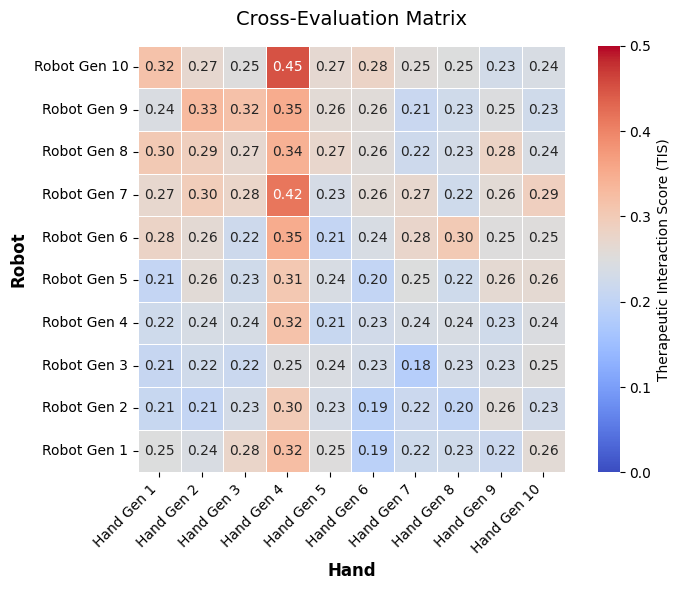

In [2]:
import gymnasium as gym
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import SAC,PPO
from custom_env import RehabilitationEnv
# from env_file import RehabilitationEnv # 确保导入你的环境类

# ================= 配置参数 =================
# 填写你刚才迭代训练保存模型的主目录
BASE_LOG_DIR = r"C:\Users\admin\Desktop\科研\RL\src\logs\iterative_training_04_07_15_20" 
ITERATIONS = 10             # 你总共迭代了多少轮
EVAL_EPISODES = 200           # 每对组合测试多少局
MAX_STEPS = 40               # 与你环境中设定的 max_steps 保持一致
ZPD_MIN = 4.0                # ZPD 的下限
ZPD_MAX = 6.0                # ZPD 的上限

def calculate_TIS(distance_history, max_steps, z_min, z_max):
    """计算单局的综合交互效能得分 (Time-Weighted EIR)"""
    if len(distance_history) == 0:
        return 0.0
    # 统计在 ZPD 区间内的帧数
    valid_frames = sum(1 for d in distance_history if z_min <= d <= z_max)
    # 得分 = 有效帧数 / 该局的最大可能步数
    tis_score = valid_frames / max_steps
    return tis_score

def evaluate_pair(robot_path, hand_path, num_episodes=50):
    """评估一对 Robot 和 Hand 的表现"""
    print(f"  Evaluating Robot: {os.path.basename(os.path.dirname(robot_path))} vs Hand: {os.path.basename(os.path.dirname(hand_path))}")
    
    # 1. 加载模型
    robot_model = PPO.load(robot_path)
    hand_model = PPO.load(hand_path) if hand_path else None

    # 2. 创建测试环境 (以 Robot 视角运行即可)
    # 注意：测试时不需要随机噪声，尽量看纯策略表现
    env = RehabilitationEnv(training_mode='robot')
    env.hand_model_pool = [hand_model] if hand_model else []
    env.random_noise = False # 建议关闭额外噪声，看纯对抗
    
    tis_scores =[]
    
    for ep in range(num_episodes):
        obs, info = env.reset()
        done = False
        truncated = False
        
        # 记录这一局的距离历史
        dist_history =[]
        
        while not (done or truncated):
            # Robot 预测动作 (确定性)
            action, _ = robot_model.predict(obs, deterministic=True)
            
            # Step
            obs, reward, done, truncated, info = env.step(action)
            
            # 记录距离
            dist_history.append(info['dist'])
            
        # 计算该局 TIS
        tis = calculate_TIS(dist_history, MAX_STEPS, ZPD_MIN, ZPD_MAX)
        tis_scores.append(tis)
        
    env.close()
    
    # 返回平均得分
    return np.mean(tis_scores)

def main():
    # 1. 搜集所有模型的路径
    robot_models = []
    hand_models =[]
    
    for i in range(1, ITERATIONS + 1):
        # 找 best_model，如果没有找 final_model
        r_best = os.path.join(BASE_LOG_DIR, f"iter_{i}", "robot", "best_model.zip")
        r_final = os.path.join(BASE_LOG_DIR, f"iter_{i}", "robot", "final_model.zip")
        robot_path = r_best if os.path.exists(r_best) else r_final
        robot_models.append((f"Robot Gen {i}", robot_path))
        
        h_best = os.path.join(BASE_LOG_DIR, f"iter_{i}", "hand", "best_model.zip")
        h_final = os.path.join(BASE_LOG_DIR, f"iter_{i}", "hand", "final_model.zip")
        hand_path = h_best if os.path.exists(h_best) else h_final
        hand_models.append((f"Hand Gen {i}", hand_path))

    # 加入 Generation 0 (Hand 是 Script，Robot 是未经迭代的)
    # 如果你想比，可以把最初的加进去，这里默认从 Gen 1 开始。
    
    num_robots = len(robot_models)
    num_hands = len(hand_models)
    
    # 2. 初始化结果矩阵
    # matrix[i][j] 表示 Robot i 对战 Hand j 的成绩
    score_matrix = np.zeros((num_robots, num_hands))
    
    print("Starting Cross-Evaluation...")
    # 3. 运行交叉评估
    for i, (r_name, r_path) in enumerate(robot_models):
        for j, (h_name, h_path) in enumerate(hand_models):
            score = evaluate_pair(r_path, h_path, num_episodes=EVAL_EPISODES)
            score_matrix[i, j] = score
            print(f"    --> Score (TIS): {score:.3f}")

    print("\nEvaluation Completed! Generating Heatmap...")

    # 4. 绘制热力图
    # 纵轴是 Robot (从上到下 Gen 1 -> Gen 5)
    # 横轴是 Hand  (从左到右 Gen 1 -> Gen 5)
    # 为了图表好看，通常把 Y 轴反转一下 (Gen 5 在最上面)
    
    plt.figure(figsize=(8, 6))
    
    # 使用 seaborn 画热力图
    # cmap="YlGnBu" 也是个好选择，这里用红蓝色系，红色代表高分
    ax = sns.heatmap(score_matrix, 
                     annot=True,          # 显示数字
                     fmt=".2f",           # 保留两位小数
                     cmap="coolwarm",     # 颜色映射 (蓝低红高)
                     vmin=0.0,            # 最小值
                     vmax=0.5,            # 最大值
                     square=True,         # 正方形格子
                     linewidths=.5,       # 格子间距
                     cbar_kws={'label': 'Therapeutic Interaction Score (TIS)'})
    
    # 设置标签
    robot_labels =[name for name, _ in robot_models]
    hand_labels =[name for name, _ in hand_models]
    
    ax.set_xticklabels(hand_labels, rotation=45, ha='right')
    ax.set_yticklabels(robot_labels, rotation=0)
    
    ax.set_xlabel('Hand', fontsize=12, fontweight='bold')
    ax.set_ylabel('Robot', fontsize=12, fontweight='bold')
    ax.set_title('Cross-Evaluation Matrix', fontsize=14, pad=15)
    
    # 如果想让最新的世代在右上角，可以颠倒Y轴
    ax.invert_yaxis()

    plt.tight_layout()
    
    # 保存图片
    save_fig_path = os.path.join(BASE_LOG_DIR, "cross_eval_heatmap.png")
    plt.savefig(save_fig_path, dpi=300)
    print(f"Heatmap saved to: {save_fig_path}")
    
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from stable_baselines3 import SAC
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

# 假设你的环境代码在当前目录下，文件名为 env_v2.py
# 如果报错，请确保 RehabilitationEnv 类定义在这个脚本里或者能被 import


# ==========================================
# 1. 实验配置
# ==========================================

# 模型路径 (请修改为你实际的路径)
PATH_MODEL_SURVIVAL = "logs/robot_stage2/1/best_model.zip" # Baseline Policy
PATH_MODEL_REHAB    = "logs/robot_stage2/14/best_model.zip"    # Ours Policy (Robot Stage 2)
PATH_META_CONTROLLER = "meta_controller.pth"               # Meta Network

# 实验参数
NUM_TEST_PATIENTS = 100   # 测试集病人数量
ASSESSMENT_SPEED = 3   # 测评阶段机器人的速度
ASSESSMENT_STEPS = 30    # 测评跑几步

# ZPD 范围 (用于计算 EIR)
ZPD_MIN, ZPD_MAX = 3.5, 6.5

# 设定一个全局随机种子
np.random.seed(42)
torch.manual_seed(42)

# ==========================================
# 2. 辅助类与函数
# ==========================================

class MetaControllerNet(nn.Module):
    def __init__(self, input_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

def calculate_cosine_alignment(hand_vec, robot_pos, hand_pos):
    """计算意图对齐度"""
    hand_speed = np.linalg.norm(hand_vec)
    target_vec = robot_pos - hand_pos
    target_dist = np.linalg.norm(target_vec)
    
    if hand_speed > 1e-4 and target_dist > 1e-4:
        cosine = np.dot(hand_vec, target_vec) / (hand_speed * target_dist)
        return cosine
    else:
        return 0.0

def extract_assessment_features(dist_history, hand_vel_history, alignment_history, robot_test_speed):
    """从测评历史提取特征 X"""
    if len(dist_history) == 0: return np.zeros(4)
    
    # 1. 速度比
    mean_hand_v = np.mean(hand_vel_history) if len(hand_vel_history) > 0 else 0
    vel_ratio = mean_hand_v / robot_test_speed
    
    # 2. 平均距离
    mean_dist = np.mean(dist_history)
    
    # 3. 覆盖率 
    coverage = np.sum(np.array(dist_history) < 6) / len(dist_history)
    
    # 4. 意图对齐度
    mean_alignment = np.mean(alignment_history) if len(alignment_history) > 0 else 0.0
        
    return np.array([vel_ratio, mean_dist, coverage, mean_alignment], dtype=np.float32)

def run_experiment_episode(env, model, speed, zpd_range, patient_params):
    """
    运行单局实验并返回指标 (SR, EIR)
    包含严格的环境重置和参数锁定逻辑
    """
    # 1. 彻底重置
    obs, _ = env.reset()
    
    # 2. [核心] 强制覆盖回指定的病人参数
    # 确保每个组面对的是完全相同的病人
    env.patient.params = patient_params.copy()
    env.patient.action_buffer.clear()
    for _ in range(env.patient.action_buffer.maxlen): 
        env.patient.action_buffer.append(np.zeros(2))
    env.patient.t = 0
    
    # 3. 应用设定的速度
    env.stride_robot = speed
    env.stride_hand = 1
  
    done = False
    dists = []
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        dists.append(info['dist'])
        done = terminated or truncated
        # print(env.hand_position,env.robot_position)
        if terminated: # 抓到了
            # print('success')
            is_success = True
            done = True
        elif truncated: # 跑掉了
            is_success = False
            done = True
    
    # 4. 计算指标
    dists = np.array(dists)
    # is_success = 1.0 if term else 0.0
    
    if len(dists) > 0:
        valid_frames = np.sum((dists >= zpd_range[0]) & (dists <= zpd_range[1]))
        eir = valid_frames / len(dists)
    else:
        eir = 0.0
    

        
    return is_success, eir,env.steps

# ==========================================
# 3. 准备阶段
# ==========================================

print(">>> Step 1: 构建标准化测试集...")
test_patient_params = []
temp_env = RehabilitationEnv() 

# 收集所有病人的 v_cap 用于计算固定步长组的基准值
all_v_caps = []

for _ in range(NUM_TEST_PATIENTS):
    params = temp_env.patient.reset_randomly()
    test_patient_params.append(params.copy())

    key = 'v_max'
    all_v_caps.append(params.get(key, 1.0))

# 计算固定步长：所有病人 v_cap 平均值的 1.0 倍 (或者你说的 1.5 倍)
FIXED_SPEED_BASELINE = min(3,np.mean(all_v_caps) * 1.5)
print(f"测试集就绪。Baseline 固定速度设为: {FIXED_SPEED_BASELINE:.2f}")


print(">>> Step 2: 加载所有模型...")
try:
    # 加载 SAC 模型
    model_survival = SAC.load(PATH_MODEL_SURVIVAL)
    model_rehab = SAC.load(PATH_MODEL_REHAB)
    
    # 加载 Meta-Controller
    meta_net = MetaControllerNet()
    try:
        meta_net.load_state_dict(torch.load(PATH_META_CONTROLLER))
        meta_net.eval()
        print("Meta-Controller 加载成功。")
    except:
        print("[Warning] Meta-Controller 未找到，将使用随机预测。")
        
except Exception as e:
    print(f"[Error] SAC 模型加载失败: {e}")
    # 为了演示，如果没模型就用 None
    model_survival = model_rehab = None

# 初始化主环境
env = RehabilitationEnv(training_mode='robot', robot_model=None, hand_model=None)

# ==========================================
# 4. 执行消融实验 (The Ablation Loop)
# ==========================================

# 定义 4 个实验组
# (Name, Model, Use_Meta)
groups = [
    ("G1: Baseline",  model_survival , False),
    ("G2: + Therapy Reward", model_rehab,    False),
    ("G3: + Meta-Control",  model_survival , True),
    ("G4: Dual-Loop Adaptation",       model_rehab,    True),
]

all_results = []

print(">>> Step 3: 开始运行消融对比...")

env.patient_locked = True
for group_name, policy_model, use_meta in groups:
    print(f"正在测试: {group_name} ...")
    
    group_sr_list = []
    group_eir_list = []

    for params in tqdm(test_patient_params):
        env.reset_patient()
        
        # --- A. 确定机器人速度 ---
        if use_meta:
            # ====================================================
            # 1. 运行多回合测评 (Assessment Phase)
            # ====================================================
            
            # 定义测评次数 (例如测 5 次取平均，数据更稳)
            NUM_ASSESSMENT_EPISODES = 10 
            
            # 数据聚合容器
            all_dists = []
            all_vels = []
            all_aligns = []
            
            # 使用躲避策略进行施压测评 (如果有的话)
            eval_policy = model_survival if model_survival else policy_model

            for _ in range(NUM_ASSESSMENT_EPISODES):
                # 绝对不要调用 env.patient.reset_randomly()，因为我们要测的是当前锁定的这个病人
                obs, _ = env.reset()
                
                # 清空动作缓存，防止上一局的延迟影响
                env.patient.action_buffer.clear()
                for _ in range(env.patient.action_buffer.maxlen): 
                    env.patient.action_buffer.append(np.zeros(2))
                
                # 强制设定为高压测评速度
                env.stride_robot = ASSESSMENT_SPEED
                
                # 单局循环
                for _ in range(ASSESSMENT_STEPS):
                    if eval_policy:
                        action, _ = eval_policy.predict(obs, deterministic=True)
                    else:
                        action = env.action_space.sample()
                    
                    obs, _, done, _, info = env.step(action)
                    
                    # 1. 收集距离
                    all_dists.append(info['dist'])
                    
                    # 2. 收集速度和对齐度
                    if len(env.hand_history_buffer) > 0:
                        v_vec = env.hand_history_buffer[-1]
                        
                        # 速度
                        all_vels.append(np.linalg.norm(v_vec))
                        
                        # 对齐度
                        align = calculate_cosine_alignment(v_vec, env.robot_position, env.hand_position)
                        all_aligns.append(align)
                    
                    if done: break
            
            # ====================================================
            # 2. 提取特征 & 推理 (Inference)
            # ====================================================
            
            # 将多回合的数据汇总在一起计算特征，这比"先算特征再平均"更鲁棒
            feats = extract_assessment_features(all_dists, all_vels, all_aligns, ASSESSMENT_SPEED)
            
            # 放入网络预测
            with torch.no_grad():
                feats_tensor = torch.FloatTensor(feats).unsqueeze(0)
                predicted_speed = meta_net(feats_tensor).item()
            
            # 限制范围 (0.5 ~ 3.5)
            final_speed = np.clip(predicted_speed, 0.5, 3)
            
        else:
            # 固定步长组
            final_speed = FIXED_SPEED_BASELINE
            

        # --- B. 运行正式实验 (Therapy Phase) ---
        # 传入当前病人参数、策略模型、确定的速度
        sr_list,eir_list = [],[]
        for _ in range(10):
            sr_i, eir_i,steps = run_experiment_episode(env, policy_model if policy_model else env, final_speed, (ZPD_MIN, ZPD_MAX), params)
            if steps > 4:
                sr_list.append(sr_i)
                eir_list.append(eir_i)
        sr, eir = np.mean(sr_list), np.mean(eir_list)
        group_sr_list.append(abs(sr-0.75))
        group_eir_list.append(eir)
        
    # --- C. 统计本组结果 ---


    # --- C. 统计本组结果 (新增方差计算) ---
    mean_sr = np.mean(group_sr_list)
    std_sr = np.std(group_sr_list)   # [新增] 成功率标准差
    
    mean_eir = np.mean(group_eir_list)
    std_eir = np.std(group_eir_list) # [新增] EIR 标准差

    tei = np.mean([eir*max(0,1-2*sr) for eir,sr in zip(group_eir_list,group_sr_list)])
    
    # TEI 计算 (保持不变)
    # tei = mean_eir * max(0, 1 - 2.0 * abs(mean_sr - 0.75))
    
    all_results.append({
        "Group": group_name,
        "SR_mean": 1-mean_sr,
        "SR_std": std_sr,
        "EIR_mean": mean_eir,
        "EIR_std": std_eir,
        "TEI": tei
    })

# ==========================================
# 5. 结果展示 (增强版绘图)
# ==========================================
# ==========================================
# 5. 结果展示 (SCI 风格 - 分栏版)
# ==========================================
df_results = pd.DataFrame(all_results)
print("\n" + "="*40)
print(" FINAL ABLATION RESULTS ")
print(df_results)
print("-" * 40)

# --- 绘图设置 ---
# 使用更高级的字体和风格
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] # SCI 论文常用字体
plt.rcParams['axes.linewidth'] = 1.5 # 坐标轴变粗

# 定义 SCI 配色 (RGB Hex)
color_sr = '#4E79A7'  # 稳重的蓝
color_eir = '#59A14F' # 自然的绿
color_tei = '#E15759' # 醒目的红
color_target = '#F28E2B' # 橙色虚线

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=150) # 高清分辨率
width = 0.35
x = np.arange(len(df_results))

# --------------------------
# 左图：基础指标对比 (SR & EIR)
# --------------------------
# 绘制 SR
rects1 = ax1.bar(x - width/2, df_results["SR_mean"], width, 
                 yerr=df_results["SR_std"], capsize=4, 
                 label='Success Rate Deviation', color=color_sr, edgecolor='white', alpha=0.9)

# 绘制 EIR
rects2 = ax1.bar(x + width/2, df_results["EIR_mean"], width, 
                 yerr=df_results["EIR_std"], capsize=4, 
                 label='Effective Guiding Ratio', color=color_eir, edgecolor='white', alpha=0.9)

# 辅助线
# ax1.axhline(0.75, color=color_target, linestyle='--', linewidth=2, label='Target ZPD (0.75)')

max_adh = df_results["SR_mean"].max()
max_eir = df_results["EIR_mean"].max()
max_tei = df_results["TEI"].max()

c_sr = '#4E79A7'  # 蓝
c_eir = '#59A14F' # 绿
c_tei = '#E15759' # 红
c_target = '#F28E2B' # 橙

ax1.axhline(max_adh, color=c_sr, linestyle='--', linewidth=2)
ax1.axhline(max_eir, color=c_eir, linestyle='--', linewidth=2)


# 装饰
ax1.set_ylabel('Metric Value', fontsize=12, fontweight='bold')
ax1.set_title('(A) Performance Metrics Comparison', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(df_results["Group"], rotation=15, ha='center', fontsize=12)
ax1.set_ylim(0, 1.15) # 留出头部空间
ax1.legend(loc='upper left', frameon=True, fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --------------------------
# 右图：综合效能得分 (TEI)
# --------------------------
# 既然 TEI 是最终得分，用单柱状图更能体现“高下立判”
rects3 = ax2.bar(x, df_results["TEI"], width*1.5, 
                 color=color_tei, edgecolor='black', alpha=0.8, label='TEI Score')

# 在柱子上标数值
for rect in rects3:
    height = rect.get_height()
    ax2.annotate(f'{height:.2f}',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 5), textcoords="offset points",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.axhline(max_tei, color=c_tei, linestyle='--', linewidth=2)

# 装饰
ax2.set_ylabel('TEI Score ', fontsize=12, fontweight='bold')
ax2.set_title('(B) Therapeutic Efficacy Index', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(df_results["Group"], rotation=15, ha='center', fontsize=12)
ax2.set_ylim(0, max(df_results["TEI"]) * 1.2) # 动态调整高度
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# --------------------------
# 整体调整
# --------------------------
plt.tight_layout()
plt.show()

env.close()

In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
from tqdm import tqdm
import pygame

# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen = pygame.display.set_mode((int(grid_s * cell_s * 1.5), int(grid_s * cell_s)))

model_robot = SAC.load("logs/robot_stage2/1/best_model.zip")
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=None)

# 实验参数
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 1.5 

# --- 核心变量 ---
env.stride_hand = 0.8          # 病人能力固定
current_robot_speed = 2.0      # 初始机器人速度
target_success_rate = 0.75     # 目标 ZPD 成功率
learning_rate = 0.5            # 调整幅度系数 (Alpha)

epochs = 50       # 总共调整 50 次难度
eval_episodes = 20 # 每次评估跑 20 局

# 记录数据
history_success_rate = []
history_difficulty = []

render = False

print("开始 Block-based ZPD 自适应测试...")

for epoch in tqdm(range(epochs), desc="Adaptive Blocks"):
    success_count = 0
    
    # --- [关键修改 1]：在整个 Block 内锁定难度 ---
    env.stride_robot = current_robot_speed
    
    for episode in range(eval_episodes):
        obs, _ = env.reset()
        # 再次确保 reset 没有重置掉我们的设定
        env.stride_robot = current_robot_speed 
        env.stride_hand = 0.8
        
        done = False
        is_success = False
        
        while not done:
            action, _ = model_robot.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            
            if render:
                env.render()
            
            if terminated: # 抓到了
                is_success = True
                done = True
            elif truncated: # 跑掉了
                is_success = False
                done = True
        
        if is_success:
            success_count += 1

    # --- [关键修改 2]：Block 结束后，根据统计结果调整 ---
    
    # 1. 计算本轮的真实成功率
    current_rate = success_count / eval_episodes
    
    # 2. 计算误差 (Error)
    # 如果 rate = 1.0 (太简单), error = +0.25 -> 速度增加
    # 如果 rate = 0.2 (太难), error = -0.55 -> 速度大减
    error = current_rate - target_success_rate
    
    # 3. 比例调整 (P-Control Update)
    # 速度变化量 = 学习率 * 误差
    # 比如: 2.0 + 0.5 * 0.25 = 2.125 (稍微加速)
    # 比如: 2.0 + 0.5 * (-0.55) = 1.725 (大幅减速)
    current_robot_speed += learning_rate * error
    
    # 4. 安全限制
    current_robot_speed = np.clip(current_robot_speed, 0.5, 5.0)
    
    # 记录数据
    history_success_rate.append(current_rate)
    history_difficulty.append(current_robot_speed)

# --- 绘图 ---
plt.figure(figsize=(12, 5))

# 图1: 成功率是否稳定在 0.75
plt.subplot(1, 2, 1)
plt.plot(history_success_rate, 'b-o', label='Block Success Rate')
plt.axhline(y=0.75, color='r', linestyle='--', label='Target (0.75)')
plt.title("ZPD Convergence")
plt.xlabel("Block Index")
plt.ylabel("Success Rate")
plt.legend()
plt.grid(True)

# 图2: 难度是否找到平衡点
plt.subplot(1, 2, 2)
plt.plot(history_difficulty, 'g-o', label='Robot Speed')
plt.title("Difficulty Adaptation")
plt.xlabel("Block Index")
plt.ylabel("Speed (cm/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
env.close()

In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
from tqdm import tqdm
import pygame

# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen = pygame.display.set_mode((int(grid_s * cell_s * 1.5), int(grid_s * cell_s)))

model_robot = SAC.load("logs/robot_stage2/1/best_model.zip")
hand_model = SAC.load("logs/hand/1/best_model.zip")
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=hand_model)

# 实验参数
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 1.5 

# --- 核心变量 ---
env.stride_hand = 0.8          # 病人能力固定
current_robot_speed = 2.0      # 初始机器人速度
target_success_rate = 0.75     # 目标 ZPD 成功率
learning_rate = 0.4            # 调整幅度系数 (Alpha)

epochs = 50       # 总共调整 50 次难度
eval_episodes = 100 # 每次评估跑 20 局

# 记录数据
history_success_rate = []
history_difficulty = []

render = False

print("开始 Block-based ZPD 自适应测试...")

for epoch in tqdm(range(epochs), desc="Adaptive Blocks"):
    success_count = 0
    
    # --- [关键修改 1]：在整个 Block 内锁定难度 ---
    env.stride_robot = current_robot_speed









    


    # 跑一遍 调整速度

    obs, _ = env.reset()
    # 再次确保 reset 没有重置掉我们的设定
    env.stride_robot = current_robot_speed 
    env.stride_hand = 0.8
    
    done = False
    is_success = False
        
    while not done:
        action, _ = model_robot.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        
        if render:
            env.render()
        
        if terminated: # 抓到了
            is_success = True
            done = True
        elif truncated: # 跑掉了
            is_success = False
            done = True
    
    if is_success:
        current_robot_speed += 0.06
    
    else:
        current_robot_speed -= 0.14



    
    for episode in range(eval_episodes):
        obs, _ = env.reset()
        # 再次确保 reset 没有重置掉我们的设定
        env.stride_robot = current_robot_speed 
        env.stride_hand = 0.8
        
        done = False
        is_success = False
        
        while not done:
            action, _ = model_robot.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            
            if render:
                env.render()
            
            if terminated: # 抓到了
                is_success = True
                done = True
            elif truncated: # 跑掉了
                is_success = False
                done = True
        
        if is_success:
            success_count += 1

    # --- [关键修改 2]：Block 结束后，根据统计结果调整 ---
    
    # 1. 计算本轮的真实成功率
    current_rate = success_count / eval_episodes

    
    # 记录数据
    history_success_rate.append(current_rate)
    history_difficulty.append(current_robot_speed)

# --- 绘图 ---
plt.figure(figsize=(12, 5))

# 图1: 成功率是否稳定在 0.75
plt.subplot(1, 2, 1)
plt.plot(history_success_rate, 'b-o', label='Success Rate')
plt.axhline(y=0.75, color='r', linestyle='--', label='Target (0.75)')
plt.title("SR Convergence")
plt.xlabel("Episodes")
plt.ylabel("Success Rate")
plt.legend()
plt.grid(True)

# 图2: 难度是否找到平衡点
plt.subplot(1, 2, 2)
plt.plot(history_difficulty, 'g-o', label='Robot Speed')
plt.title("Difficulty Adaptation")
plt.xlabel("Episodes")
plt.ylabel("Speed (cm/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
env.close()

In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
from tqdm import tqdm
import pygame

# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen = pygame.display.set_mode((int(grid_s * cell_s * 1.5), int(grid_s * cell_s)))

model_robot = SAC.load("logs/robot_stage2/1/best_model.zip")
hand_model = SAC.load("logs/hand/1/best_model.zip")
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=hand_model)

# 实验参数
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 1.5 

# --- 核心变量 ---
env.stride_hand = 0.8          # 病人能力固定
current_robot_speed = 2.0      # 初始机器人速度
target_success_rate = 0.75     # 目标 ZPD 成功率
learning_rate = 0.5            # 调整幅度系数 (Alpha)

epochs = 50       # 总共调整 50 次难度
eval_episodes = 20 # 每次评估跑 20 局

# 记录数据
history_success_rate = []
history_difficulty = []

render = False

print("开始 Block-based ZPD 自适应测试...")




# 设置robot 为固定轨迹


obs, _ = env.reset()
done = False
is_success = False

info_list = []
while not done:
    # action, _ = model_robot.predict(obs, deterministic=True)
    # 固定让robot 横着走
    action = np.array([0.8, 0.0])  # 横向移动
    obs, reward, terminated, truncated, info = env.step(action)

    info_list.append(info['dist'])
    
    if render:
        hand_position = render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)
    
    if terminated: # 抓到了
        is_success = True
        done = True
    elif truncated: # 跑掉了
        is_success = False
        done = True

if is_success:
    success_count += 1







for epoch in tqdm(range(epochs), desc="Adaptive Blocks"):
    success_count = 0
    
    # --- [关键修改 1]：在整个 Block 内锁定难度 ---
    env.stride_robot = current_robot_speed
    
    for episode in range(eval_episodes):
        obs, _ = env.reset()
        info = env._get_info()
        # 再次确保 reset 没有重置掉我们的设定
        env.stride_robot = current_robot_speed 
        env.stride_hand = 0.8
        
        done = False
        is_success = False
        
        while not done:
            action, _ = model_robot.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            
            if render:
                hand_position = render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)

            
            if terminated: # 抓到了
                is_success = True
                done = True
            elif truncated: # 跑掉了
                is_success = False
                done = True
        
        if is_success:
            success_count += 1

    # --- [关键修改 2]：Block 结束后，根据统计结果调整 ---
    
    # 1. 计算本轮的真实成功率
    current_rate = success_count / eval_episodes
    
    # 2. 计算误差 (Error)
    # 如果 rate = 1.0 (太简单), error = +0.25 -> 速度增加
    # 如果 rate = 0.2 (太难), error = -0.55 -> 速度大减
    error = current_rate - target_success_rate
    
    # 3. 比例调整 (P-Control Update)
    # 速度变化量 = 学习率 * 误差
    # 比如: 2.0 + 0.5 * 0.25 = 2.125 (稍微加速)
    # 比如: 2.0 + 0.5 * (-0.55) = 1.725 (大幅减速)
    current_robot_speed += learning_rate * error
    
    # 4. 安全限制
    current_robot_speed = np.clip(current_robot_speed, 0.5, 5.0)


    success_count = 0


    for episode in range(100):
        obs, _ = env.reset()
        info = env._get_info()
        # 再次确保 reset 没有重置掉我们的设定
        env.stride_robot = current_robot_speed 
        env.stride_hand = 0.8
        
        done = False
        is_success = False
        
        while not done:
            action, _ = model_robot.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            
            if render:
                hand_position = render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)

            
            if terminated: # 抓到了
                is_success = True
                done = True
            elif truncated: # 跑掉了
                is_success = False
                done = True
        
        if is_success:
            success_count += 1

    # --- [关键修改 2]：Block 结束后，根据统计结果调整 ---
    
    # 1. 计算本轮的真实成功率
    current_rate = success_count / 100
    
    # 记录数据
    history_success_rate.append(current_rate)
    history_difficulty.append(current_robot_speed)

# --- 绘图 ---
plt.figure(figsize=(12, 5))

# 图1: 成功率是否稳定在 0.75
plt.subplot(1, 2, 1)
plt.plot(history_success_rate, 'b-o', label='Block Success Rate')
plt.axhline(y=0.75, color='r', linestyle='--', label='Target (0.75)')
plt.title("ZPD Convergence")
plt.xlabel("Episodes")
plt.ylabel("Success Rate")
plt.legend()
plt.grid(True)

# 图2: 难度是否找到平衡点
plt.subplot(1, 2, 2)
plt.plot(history_difficulty, 'g-o', label='Robot Speed')
plt.title("Difficulty Adaptation")
plt.xlabel("Episodes")
plt.ylabel("Speed (cm/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
env.close()

In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
import pygame

# --- 1. 实验设置 ---
# 定义 ZPD (最近发展区) 的距离范围 (单位: Grid/cm)
# 这个范围由你之前的 Reward Function 决定
ZPD_MIN = 3  # 太近了 (危险/已抓到)
ZPD_MAX = 5  # 太远了 (脱离交互)

# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen_width = int(grid_s * cell_s * 1.5)
screen_height = int(grid_s * cell_s)
screen = pygame.display.set_mode((screen_width, screen_height))

# 加载模型
# 请确保路径正确
model_path = "logs/robot_stage2/4/best_model.zip" 
try:
    model_robot = SAC.load(model_path)
    print(f"成功加载模型: {model_path}")
except:
    print("模型加载失败，请检查路径。这里使用随机策略演示。")
    model_robot = None

hand_model = SAC.load("logs/hand/1/best_model.zip")

# 创建环境
# 注意：这里我们测试的是 Robot，Hand 用默认脚本即可
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=hand_model)

# 实验参数覆盖
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 2.5  # 抓取判定
env.stride_hand = 0.8                   # 模拟一个中等速度的病人
env.stride_robot = 2.0                  # 设定机器人的能力

render = False  # 是否显示 Pygame 窗口

print(f"开始 ZPD 保持能力测试 (Target Range: {ZPD_MIN} - {ZPD_MAX})...")


global_eir_list = []
global_success_rate_list = []
global_avg_dist_list = []

for i in range(10):
    eir_list = []
    dist_list = []
    success_count = 0
    for episode in range(1000):  # 这里只跑一局测试
    # --- 2. 运行单局测试 ---
        obs, _ = env.reset()
        env.stride_hand = 0.8+0.1*i                   # 模拟一个中等速度的病人
        env.stride_robot = 2.5                  # 设定机器人的能力
        env.distance_threshold_collision = 2.5  # 抓取判定
        env.max_steps = 20
        done = False
        is_success = False

        # 记录器
        history_dist = []
        history_hand_vel = []

        while not done:
            # A. 机器人决策
            if model_robot:
                action, _ = model_robot.predict(obs, deterministic=True)
            else:
                action = env.action_space.sample() # 随机动作作为 fallback

            # B. 环境步进
            obs, reward, terminated, truncated, info = env.step(action)

            # C. 记录数据
            # 计算当前距离 (Info里可能有，也可以自己算)
            current_dist = np.linalg.norm(env.robot_position - env.hand_position)
            history_dist.append(current_dist)
            
            # 记录手部速度 (用于分析机器人是否跟丢了)
            if len(env.hand_history_buffer) > 0:
                hand_v = np.linalg.norm(env.hand_history_buffer[-1])
                history_hand_vel.append(hand_v)

            # D. 渲染
            if render:
                # 这里调用你之前的 render_aesthetic 或者 env 自带的 render
                # 为了通用性，这里调用 env.render()，你可以换回你的 aesthetic 版本
                env.render() 
                # time.sleep(0.05) # 如果太快看不清可以加延时

            # E. 结束判定
            if terminated: # 抓到了
                is_success = True
                success_count += 1
                done = True
                # print("Result: Success (Caught)")
            elif truncated: # 超时/跑掉了
                is_success = False
                done = True
                # print("Result: Timeout/Escaped")

        # --- 3. 计算指标 ---
        dist_array = np.array(history_dist)
        total_frames = len(dist_array)

        # 计算在 ZPD 区间内的帧数
        in_zone_frames = np.sum((dist_array >= ZPD_MIN) & (dist_array <= ZPD_MAX))

        # 计算 EIR (Effective Interaction Ratio)
        eir = in_zone_frames / total_frames if total_frames > 0 else 0


        if total_frames > 5:
            eir_list.append(eir)
            dist_list.append(total_frames)



        # print("-" * 30)
        # print(f"实验报告:")
        # print(f"总时长: {total_frames} 帧")
        # print(f"ZPD 区间: [{ZPD_MIN}, {ZPD_MAX}]")
        # print(f"有效交互比率 (EIR): {eir * 100:.2f}%")
        # print("-" * 30)

        # --- 4. 绘图分析 (论文图表) ---
        # plt.figure(figsize=(10, 5))

        # # 绘制距离曲线
        # plt.plot(dist_array, label='Real-time Distance', color='#2980b9', linewidth=2)

        # # 绘制 ZPD 区域 (绿色背景带)
        # plt.axhspan(ZPD_MIN, ZPD_MAX, color='#2ecc71', alpha=0.2, label='ZPD (Optimal Zone)')

        # # 绘制危险区 (红色背景带 - 太近)
        # plt.axhspan(0, ZPD_MIN, color='#e74c3c', alpha=0.1, label='Too Close (<2.0)')

        # # 绘制脱离区 (灰色背景带 - 太远)
        # # 假设最大显示距离为 15
        # plt.axhspan(ZPD_MAX, 15, color='#95a5a6', alpha=0.1, label='Too Far (>6.0)')

        # # 标注平均距离
        # mean_dist = np.mean(dist_array)
        # plt.axhline(y=mean_dist, color='#e67e22', linestyle='--', label=f'Mean Dist: {mean_dist:.2f}')

        # plt.title(f'Robot Capability to Maintain ZPD (EIR: {eir*100:.1f}%)')
        # plt.xlabel('Time Step')
        # plt.ylabel('Distance (Grid Units)')
        # plt.legend(loc='upper right')
        # plt.grid(True, alpha=0.3)
        # plt.ylim(0, 12) # 固定 Y 轴范围方便观察

        # plt.tight_layout()
        # plt.show()

        # 关闭环境
        env.close()

    # print("=== 总结报告 ===")
    # print(f"平均有效交互比率 (EIR) over 100 episodes: {np.mean(eir_list) * 100:.2f}%")
    # print(f"成功率: {success_count / 10:.2f}%")
    global_eir_list.append(np.mean(eir_list).item())
    global_success_rate_list.append(success_count / 1000)
    global_avg_dist_list.append(np.mean(dist_list))

print("=== 全局总结报告 ===")
print(global_eir_list)
print(global_success_rate_list)



In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
import pygame

# --- 1. 实验设置 ---
# 定义 ZPD (最近发展区) 的距离范围 (单位: Grid/cm)
# 这个范围由你之前的 Reward Function 决定
ZPD_MIN = 3  # 太近了 (危险/已抓到)
ZPD_MAX = 5  # 太远了 (脱离交互)

# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen_width = int(grid_s * cell_s * 1.5)
screen_height = int(grid_s * cell_s)
screen = pygame.display.set_mode((screen_width, screen_height))

# 加载模型
# 请确保路径正确
model_path = "logs/robot_stage2/5/best_model.zip" 
try:
    model_robot = SAC.load(model_path)
    print(f"成功加载模型: {model_path}")
except:
    print("模型加载失败，请检查路径。这里使用随机策略演示。")
    model_robot = None

hand_model = SAC.load("logs/hand/1/best_model.zip")
# 创建环境
# 注意：这里我们测试的是 Robot，Hand 用默认脚本即可
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=hand_model)

# 实验参数覆盖
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 2.5  # 抓取判定
env.stride_hand = 0.8                   # 模拟一个中等速度的病人
env.stride_robot = 2.0                  # 设定机器人的能力

render = False  # 是否显示 Pygame 窗口

print(f"开始 ZPD 保持能力测试 (Target Range: {ZPD_MIN} - {ZPD_MAX})...")


global_eir_list2 = []
global_success_rate_list2 = []
global_avg_dist_list2 = []

for i in range(10):
    eir_list = []
    success_count = 0
    dist_list = []
    for episode in range(1000):  # 这里只跑一局测试
    # --- 2. 运行单局测试 ---
        obs, _ = env.reset()
        env.stride_hand = 0.8+0.1*i                   # 模拟一个中等速度的病人
        env.stride_robot = 2.5                  # 设定机器人的能力
        env.distance_threshold_collision = 2.5  # 抓取判定
        env.max_steps = 20
        done = False
        is_success = False

        # 记录器
        history_dist = []
        history_hand_vel = []

        while not done:
            # A. 机器人决策
            if model_robot:
                action, _ = model_robot.predict(obs, deterministic=True)
            else:
                action = env.action_space.sample() # 随机动作作为 fallback

            # B. 环境步进
            obs, reward, terminated, truncated, info = env.step(action)

            # C. 记录数据
            # 计算当前距离 (Info里可能有，也可以自己算)
            current_dist = np.linalg.norm(env.robot_position - env.hand_position)
            history_dist.append(current_dist)
            
            # 记录手部速度 (用于分析机器人是否跟丢了)
            if len(env.hand_history_buffer) > 0:
                hand_v = np.linalg.norm(env.hand_history_buffer[-1])
                history_hand_vel.append(hand_v)

            # D. 渲染
            if render:
                # 这里调用你之前的 render_aesthetic 或者 env 自带的 render
                # 为了通用性，这里调用 env.render()，你可以换回你的 aesthetic 版本
                env.render() 
                # time.sleep(0.05) # 如果太快看不清可以加延时

            # E. 结束判定
            if terminated: # 抓到了
                is_success = True
                success_count += 1
                done = True
                # print("Result: Success (Caught)")
            elif truncated: # 超时/跑掉了
                is_success = False
                done = True
                # print("Result: Timeout/Escaped")

        # --- 3. 计算指标 ---
        dist_array = np.array(history_dist)
        total_frames = len(dist_array)

        # 计算在 ZPD 区间内的帧数
        in_zone_frames = np.sum((dist_array >= ZPD_MIN) & (dist_array <= ZPD_MAX))

        # 计算 EIR (Effective Interaction Ratio)
        eir = in_zone_frames / total_frames if total_frames > 0 else 0


        if total_frames > 5:
            eir_list.append(eir)
            dist_list.append(total_frames)



        # print("-" * 30)
        # print(f"实验报告:")
        # print(f"总时长: {total_frames} 帧")
        # print(f"ZPD 区间: [{ZPD_MIN}, {ZPD_MAX}]")
        # print(f"有效交互比率 (EIR): {eir * 100:.2f}%")
        # print("-" * 30)

        # --- 4. 绘图分析 (论文图表) ---
        # plt.figure(figsize=(10, 5))

        # # 绘制距离曲线
        # plt.plot(dist_array, label='Real-time Distance', color='#2980b9', linewidth=2)

        # # 绘制 ZPD 区域 (绿色背景带)
        # plt.axhspan(ZPD_MIN, ZPD_MAX, color='#2ecc71', alpha=0.2, label='ZPD (Optimal Zone)')

        # # 绘制危险区 (红色背景带 - 太近)
        # plt.axhspan(0, ZPD_MIN, color='#e74c3c', alpha=0.1, label='Too Close (<2.0)')

        # # 绘制脱离区 (灰色背景带 - 太远)
        # # 假设最大显示距离为 15
        # plt.axhspan(ZPD_MAX, 15, color='#95a5a6', alpha=0.1, label='Too Far (>6.0)')

        # # 标注平均距离
        # mean_dist = np.mean(dist_array)
        # plt.axhline(y=mean_dist, color='#e67e22', linestyle='--', label=f'Mean Dist: {mean_dist:.2f}')

        # plt.title(f'Robot Capability to Maintain ZPD (EIR: {eir*100:.1f}%)')
        # plt.xlabel('Time Step')
        # plt.ylabel('Distance (Grid Units)')
        # plt.legend(loc='upper right')
        # plt.grid(True, alpha=0.3)
        # plt.ylim(0, 12) # 固定 Y 轴范围方便观察

        # plt.tight_layout()
        # plt.show()

        # 关闭环境
        env.close()

    # print("=== 总结报告 ===")
    # print(f"平均有效交互比率 (EIR) over 100 episodes: {np.mean(eir_list) * 100:.2f}%")
    # print(f"成功率: {success_count / 10:.2f}%")
    global_eir_list2.append(np.mean(eir_list).item())
    global_success_rate_list2.append(success_count / 1000)
    global_avg_dist_list2.append(np.mean(dist_list).item())

print("=== 全局总结报告 ===")
print(global_eir_list2)
print(global_success_rate_list2)

In [ ]:
from matplotlib import pyplot as plt

# 假设 x 轴数据 (如果你的数据长度不一定是10，可以用 len(global_eir_list) 代替)
x_data = [0.8 + 0.1*i for i in range(10)]

# 设置画布大小
plt.figure(figsize=(16, 4))

# ==========================================
# 图1: EIR 对比
# ==========================================
plt.subplot(1, 3, 1)

# Model 1 (蓝色圆点实线)
plt.plot(x_data, global_eir_list, 
         color='tab:blue', marker='o', linestyle='-', linewidth=2, 
         label='baseline') # 建议改成具体模型名字，如 'Baseline'

# Model 2 (橙色方块虚线) - 换颜色和形状以区分
plt.plot(x_data, global_eir_list2, 
         color='tab:orange', marker='s', linestyle='--', linewidth=2, 
         label='improved') # 建议改成具体模型名字，如 'Ours'

plt.title("Effective Guiding Ratio", fontsize=14,pad=12)
plt.xlabel("Hand Speed", fontsize=12)
plt.ylabel("EIR", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # 网格线弄淡一点
plt.legend(fontsize=10) # 显示图例

# ==========================================
# 图2: 成功率对比
# ==========================================
plt.subplot(1, 3, 2)


# global_success_rate_list = [x*100 for x in global_success_rate_list]
# global_success_rate_list2 = [x*100 for x in global_success_rate_list2]
# Model 1
plt.plot(x_data, global_success_rate_list, 
         color='tab:blue', marker='o', linestyle='-', linewidth=2, 
         label='baseline')

# Model 2
plt.plot(x_data, global_success_rate_list2, 
         color='tab:orange', marker='s', linestyle='--', linewidth=2, 
         label='improved')
plt.axhline(y=0.75, color='r', linestyle='--', label='Ideal (0.75)')

plt.axhspan(ymin=0.65, ymax=0.85, color='gray', alpha=0.2, label='ZPD')

plt.title("Success Rate", fontsize=14, pad=12)
plt.xlabel("Hand Speed", fontsize=12)
plt.ylabel("Success Ratio", fontsize=12)
# 如果成功率是0-1之间，可以固定Y轴范围让对比更明显
plt.ylim(-0.05, 1.05) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)


# 距离对比图
plt.subplot(1, 3, 3)
plt.plot(x_data, global_avg_dist_list, color='tab:blue', marker='o', linestyle='-', linewidth=2, label='baseline')
plt.plot(x_data, global_avg_dist_list2, color='tab:orange', marker='s', linestyle='--', linewidth=2, label='improved')

plt.title("Average Step", fontsize=14, pad=12)
plt.xlabel("Hand Speed", fontsize=12)
plt.ylabel("Average Step", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)



# 自动调整布局防止重叠
# plt.tight_layout(pad=4.0, h_pad=4.0, w_pad=3.0)
plt.show()

In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
import pygame



# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen_width = int(grid_s * cell_s * 1.5)
screen_height = int(grid_s * cell_s)
screen = pygame.display.set_mode((screen_width, screen_height))

# 加载模型
# 请确保路径正确
model_path = "logs/robot_stage2/4/best_model.zip" 
try:
    model_robot = SAC.load(model_path)
    print(f"成功加载模型: {model_path}")
except:
    print("模型加载失败，请检查路径。这里使用随机策略演示。")
    model_robot = None

hand_model = SAC.load("logs/hand/1/best_model.zip")
# 创建环境
# 注意：这里我们测试的是 Robot，Hand 用默认脚本即可
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=hand_model)

# 实验参数覆盖
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 2.5  # 抓取判定
env.stride_hand = 0.8                   # 模拟一个中等速度的病人
env.stride_robot = 2.0                  # 设定机器人的能力

render = False  # 是否显示 Pygame 窗口

print(f"开始 ZPD 保持能力测试 (Target Range: {ZPD_MIN} - {ZPD_MAX})...")


global_eir_list2 = []
global_success_rate_list2 = []
global_avg_dist_list2 = []

for i in range(10):
    eir_list = []
    success_count = 0

    dist_list = []
    hand_vel_list = []
    for episode in range(10):  # 这里只跑一局测试
    # --- 2. 运行单局测试 ---
        obs, _ = env.reset()
        env.stride_hand = 0.5+0.05*i                   # 模拟一个中等速度的病人
        env.stride_robot = 3                  # 设定机器人的能力
        env.distance_threshold_collision = 2.5  # 抓取判定
        env.max_steps = 20
        done = False
        is_success = False

        # 记录器
        history_dist = []
        history_hand_vel = []

        while not done:
            # A. 机器人决策
            if model_robot:
                action, _ = model_robot.predict(obs, deterministic=True)
            else:
                action = env.action_space.sample() # 随机动作作为 fallback

            # B. 环境步进
            obs, reward, terminated, truncated, info = env.step(action)

            # C. 记录数据
            # 计算当前距离 (Info里可能有，也可以自己算)
            current_dist = np.linalg.norm(env.robot_position - env.hand_position)
            history_dist.append(current_dist)
            
            # 记录手部速度 (用于分析机器人是否跟丢了)
            if len(env.hand_history_buffer) > 0:
                hand_v = np.linalg.norm(env.hand_history_buffer[-1])
                history_hand_vel.append(hand_v)

            # D. 渲染
            if render:
                # 这里调用你之前的 render_aesthetic 或者 env 自带的 render
                # 为了通用性，这里调用 env.render()，你可以换回你的 aesthetic 版本
                env.render() 
                # time.sleep(0.05) # 如果太快看不清可以加延时

            # E. 结束判定
            if terminated: # 抓到了
                is_success = True
                success_count += 1
                done = True
                # print("Result: Success (Caught)")
            elif truncated: # 超时/跑掉了
                is_success = False
                done = True
                # print("Result: Timeout/Escaped")

        # --- 3. 计算指标 ---
        dist_array = np.array(history_dist)
        total_frames = len(dist_array)
        



        if total_frames > 5:
            eir_list.append(eir)
            dist_list.append(total_frames)

        dist_list.append(np.mean(dist_array).item())
        hand_vel_list.append(np.mean(history_hand_vel).item())

        # print("-" * 30)
        # print(f"实验报告:")
        # print(f"总时长: {total_frames} 帧")
        # print(f"ZPD 区间: [{ZPD_MIN}, {ZPD_MAX}]")
        # print(f"有效交互比率 (EIR): {eir * 100:.2f}%")
        # print("-" * 30)

        # --- 4. 绘图分析 (论文图表) ---
        # plt.figure(figsize=(10, 5))

        # # 绘制距离曲线
        # plt.plot(dist_array, label='Real-time Distance', color='#2980b9', linewidth=2)

        # # 绘制 ZPD 区域 (绿色背景带)
        # plt.axhspan(ZPD_MIN, ZPD_MAX, color='#2ecc71', alpha=0.2, label='ZPD (Optimal Zone)')

        # # 绘制危险区 (红色背景带 - 太近)
        # plt.axhspan(0, ZPD_MIN, color='#e74c3c', alpha=0.1, label='Too Close (<2.0)')

        # # 绘制脱离区 (灰色背景带 - 太远)
        # # 假设最大显示距离为 15
        # plt.axhspan(ZPD_MAX, 15, color='#95a5a6', alpha=0.1, label='Too Far (>6.0)')

        # # 标注平均距离
        # mean_dist = np.mean(dist_array)
        # plt.axhline(y=mean_dist, color='#e67e22', linestyle='--', label=f'Mean Dist: {mean_dist:.2f}')

        # plt.title(f'Robot Capability to Maintain ZPD (EIR: {eir*100:.1f}%)')
        # plt.xlabel('Time Step')
        # plt.ylabel('Distance (Grid Units)')
        # plt.legend(loc='upper right')
        # plt.grid(True, alpha=0.3)
        # plt.ylim(0, 12) # 固定 Y 轴范围方便观察

        # plt.tight_layout()
        # plt.show()

        # 关闭环境
        env.close()


    print(f"平均距离: {np.mean(dist_list):.2f}")
    print(f"平均手部速度: {np.mean(hand_vel_list):.2f}")

